# THE SETUP

Want to dive a little bit deeper into gradient and activation flow through the MLP from last session.

**WHY??** \
In the coming sessions, we'll be understanding why RNNs have an optimization bottleneck(with first order GD). This makes RNNs less useful despite them being "universal approximators" in principle. Understanding gradient flow helps realize this issue.

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

## READ NAMES DATA

In [ ]:
names = open('names.txt', 'r').read().splitlines()
names[:5]

['emma', 'olivia', 'ava', 'isabella', 'sophia']

In [ ]:
len(names)

32033

In [ ]:
min(len(n) for n in names)

2

In [ ]:
max(len(n) for n in names)

15

## CREATE VOCABULARY

In [ ]:
vocabulary = sorted(list(set(''.join(names))))
stoi = {s:i+1 for i, s in enumerate(vocabulary)}
stoi['.']=0

itos = {i:s for s,i in stoi.items()}

In [ ]:
vocab_size = len(itos)
vocab_size

27

In [ ]:
names[:3]

['emma', 'olivia', 'ava']

## GENERATE DATASET

In [ ]:

block_size = 3
def build_dataset(names):

  x = []
  y = []

  for name in names:
    context = [0]*block_size
    for ch in name + '.':
      x.append(context)
      ix = stoi[ch]
      y.append(ix)
      context = context[1:] + [ix]

  xs = torch.tensor(x)
  ys = torch.tensor(y)
  return xs, ys

In [ ]:
import random
random.seed(42)
random.shuffle(names)

n1 = int(0.8*len(names))
n2 = int(0.9*len(names))

xTr, yTr = build_dataset(names[:n1])
xVal, yVal = build_dataset(names[n1:n2])
xTe, yTe = build_dataset(names[n2:])

print(xTr.shape, yTr.shape)
print(xVal.shape, yVal.shape)
print(xTe.shape, yTe.shape)

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [ ]:
xTr.shape

torch.Size([182625, 3])

## MLP

In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
B1 = torch.randn(hidden_size,                            generator=g)
W2 = torch.randn((hidden_size, vocab_size),              generator=g)
B2 = torch.randn(vocab_size,                             generator=g)

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

11897


In [ ]:
xTr[0]

tensor([0, 0, 0])

In [ ]:
num_epochs = 200000
batch_size = 32

log_loss = []


for i in range(num_epochs):

  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hidden = torch.tanh(embed.view(xTr[ind].shape[0], -1) @ W1 + B1)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None

  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01

  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')

  log_loss.append(loss.log10().item())


      0/ 200000:27.8817
  10000/ 200000:2.9415
  20000/ 200000:2.5069
  30000/ 200000:2.7998
  40000/ 200000:2.0261
  50000/ 200000:2.5863
  60000/ 200000:2.3420
  70000/ 200000:2.0952
  80000/ 200000:2.3454
  90000/ 200000:2.2365
 100000/ 200000:2.1080
 110000/ 200000:2.3831
 120000/ 200000:1.9898
 130000/ 200000:2.4591
 140000/ 200000:2.1910
 150000/ 200000:2.1606
 160000/ 200000:2.1811
 170000/ 200000:1.7997
 180000/ 200000:2.0962
 190000/ 200000:1.8052


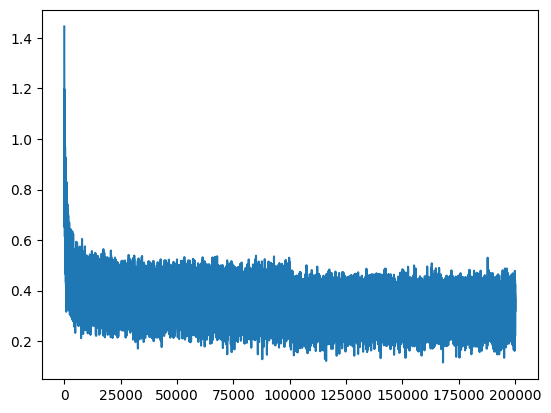

In [ ]:
plt.plot(log_loss)

## CALCULATE LOSS

In [ ]:
# decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hidden = torch.tanh(embed.view(x.shape[0], -1)@ W1 + B1) # (N, hidden_size)
  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.127678871154785
val 2.1750576496124268


Decorator ```@torch.no_grad()``` equivalent use as Context Manager ```with torch.no_grad():```

## INFERENCE

In [ ]:
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):

  out = []
  context  = [0]*block_size
  while True:

    embed = C[context]
    hidden = torch.tanh(embed.view(1, -1) @ W1 + B1)
    logits = hidden @ W2 + B2

    prob = F.softmax(logits, dim=1) # important to mention softmax dimension
    ix = torch.multinomial(prob, num_samples=1, generator=g).item()
    out.append(itos[ix])
    if ix == 0:
      break
    context = context[1:] + [ix]

  print(''.join(out))

mora.
mayah.
seel.
nehayla.
remyra.
endrael.
adeer.
melin.
shy.
jen.
ede.
seananaraelyn.
malya.
cayshubergiaghan.
trickontelionnie.
cayus.
mace.
ryyah.
fael.
youe.


# LOT OF PROBLEMS TO FIX:

```
      train 2.1211986541748047
      val 2.1612391471862793
```

1.   Poor initialization - loss jump between 1st epoch and subsequent epochs is massive, indicating an initialization issue
```
    train 2.0686392784118652
    val 2.132765531539917
```  
    

    
2.   Saturated tanh - most values after tanh activation are squished toward the extremities of the tanh function i.e 1 or -1
```
    train 2.034301996231079
    val 2.1022725105285645
```

  ```
    # kaiming
    train 2.037754774093628
    val 2.1032512187957764
  ```

3.  Batch Normalization

    *   Unlearned - immovable - limits learning in the network
        ```
          train 2.7043747901916504
          val 2.762363910675049
        ```
    *   Learned - movable with γ and β (with kaiming)
        ```
          train 2.0613129138946533
          val 2.1078107357025146
        ```
    *   Learned - movable with γ and β (w/o kaiming)
        ```
          train 2.1112782955169678
          val 2.138336420059204
        ```
    *   Learned - movable with γ and β (w/o kaiming) (train stats used in eval)
        ```
          train 2.1112782955169678
          val 2.138324499130249
        ```
    *   Learned - movable with γ and β (with kaiming) (running train stats used in eval)
        ```
          train 2.065549850463867
          val 2.111138343811035
        ```


        

    
    



### 1. Poor Initialization

In [ ]:
# 4-dimensional example of issue
## WHEN ALL LOGITS ARE 0, LOSS IS LOW
logits = torch.tensor([0.0, 0.0, 0.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.2500, 0.2500, 0.2500, 0.2500]), tensor(1.3863))

In [ ]:
# 4-dimensional example of issue
## IF THE LOGIT CORRESPONDING TO OUR LABEL IS FORTUNATELY HIGHEST, LOSS IS LOWEST
logits = torch.tensor([0.0, 0.0, 5.0, 0.0])
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.0066, 0.0066, 0.9802, 0.0066]), tensor(0.0200))

In [ ]:
# 4-dimensional example of issue
## BUT AT RANDOM INITIALIZATION, THIS LOSS CAN BE ARBITRARILY HIGH OR LOW
logits = torch.randn(4)
probs = torch.softmax(logits, dim=0)
loss = -probs[2].log()
probs, loss

(tensor([0.4363, 0.0803, 0.3429, 0.1405]), tensor(1.0704))

In [ ]:
## Ideally at initialization we would want all possible outcomes to at least have equal probabilities
## in our case with 27 output character possibilities, this would lead to a uniform 1/27 prob distribution
## making the max possible loss 3.2958 as opposed to our recorded 0/ 200000:25.9595
loss = -torch.tensor(1/27).log()
loss

tensor(3.2958)

Here's what logits look like after first step without a fix

In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
B1 = torch.randn(hidden_size,                            generator=g)
W2 = torch.randn((hidden_size, vocab_size),              generator=g)
B2 = torch.randn(vocab_size,                             generator=g)

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True

11897


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hidden = torch.tanh(embed.view(xTr[ind].shape[0], -1) @ W1 + B1)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())
  break

      0/ 200000:27.8817


In [ ]:
logits[0] # not almost all equal - which is what we'd like it to be in the beginning

tensor([ -2.3527,  36.4366, -10.7306,   5.7165,  18.6409, -11.6998,  -2.1991,
          1.8535,  10.9996,  10.6730,  12.3507, -10.3809,   4.7243, -24.4257,
         -8.5909,   1.9024, -12.2744, -12.4751, -23.2778,  -2.0163,  25.8767,
         14.2108,  17.7691, -10.9204, -20.7335,   6.4560,  11.1615],
       grad_fn=<SelectBackward0>)

So what's the fix??

we can set the initial bias B2 to 0 and set the initial W2 to be very very low

This way - the output after hidden @ W2 + B2 will be very small values across the board

In [ ]:
def reinitialize_model():
  vocab_size = 27
  embed_size = 10
  hidden_size = 200

  g = torch.Generator().manual_seed(2147483647)
  C = torch.randn((vocab_size, embed_size),                generator=g)
  W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
  B1 = torch.randn(hidden_size,                            generator=g)
  W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
  B2 = torch.randn(vocab_size,                             generator=g) * 0

  parameters = [C, W1, B1, W2, B2]
  print(sum(p.nelement() for p in parameters))

  for p in parameters:
    p.requires_grad = True

  return C, W1, B1, W2, B2, parameters

In [ ]:
C, W1, B1, W2, B2, parameters = reinitialize_model()

11897


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hidden = torch.tanh(embed.view(xTr[ind].shape[0], -1) @ W1 + B1)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())
  break

      0/ 200000:3.2991


In [ ]:
logits[0]

tensor([-0.0800, -0.2053,  0.0379, -0.0789,  0.1681,  0.2027, -0.1977, -0.0478,
        -0.1928,  0.0926,  0.1181, -0.0197,  0.0113, -0.1706,  0.0709,  0.1227,
         0.0275,  0.2161,  0.0497,  0.0706, -0.0182, -0.0188, -0.1570,  0.0323,
         0.0557,  0.0917,  0.1919], grad_fn=<SelectBackward0>)

So now we get a loss of 3.3044 which is very close to the uniform loss:

$-torch.tensor(1/27).log() = 3.2958$

### Q: but then why can't we just set W2 = 0, which'll make all the initial logits = 0 and uniform.

This approach has an issue: which we'll see later
# ANS:

Scaling down to zero can mask incorrect implementations of the backward pass(in the case that it is implemented manually pynb 5.0)

### Let's see how the fix fixes the training

In [ ]:
C, W1, B1, W2, B2, parameters = reinitialize_model()

11897


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1
  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3357
  10000/ 200000:2.3494
  20000/ 200000:1.8692
  30000/ 200000:2.0855
  40000/ 200000:2.0258
  50000/ 200000:2.1447
  60000/ 200000:2.1717
  70000/ 200000:2.6000
  80000/ 200000:2.2967
  90000/ 200000:2.1090
 100000/ 200000:2.2376
 110000/ 200000:2.7308
 120000/ 200000:2.0148
 130000/ 200000:2.2936
 140000/ 200000:1.9810
 150000/ 200000:1.7064
 160000/ 200000:2.0541
 170000/ 200000:2.1686
 180000/ 200000:2.1022
 190000/ 200000:1.6631


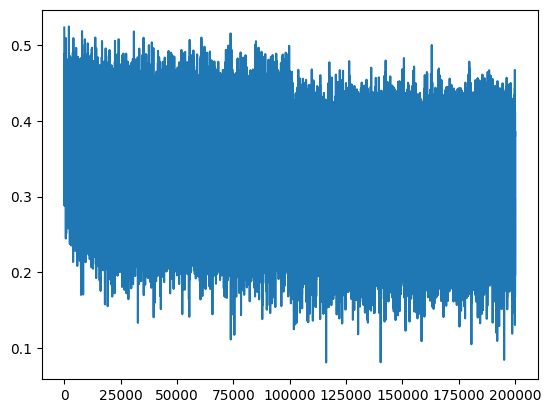

In [ ]:
plt.plot(log_loss) ## No more hockey stick

So we essentially obviated the task of squashing down the logits from extremely random values to values in similar ranges.

Now the training can focus on the actual work

In [ ]:
split_loss('train')
split_loss('val')

train 2.0688276290893555
val 2.1299972534179688


## 2. Saturated tanh

In [ ]:
hidden[0] ## most values after tanh activation are either -1 or 1

tensor([ 0.9747,  0.7376,  0.9919,  1.0000, -0.4828, -0.9979, -0.4447, -0.8067,
        -0.9989, -0.6113,  1.0000, -0.9999,  0.1500, -0.7077,  0.8064, -0.9997,
         0.9988, -0.8413, -1.0000, -1.0000,  0.9999,  0.9868, -0.8527, -0.4973,
         0.3655,  0.9499,  1.0000, -0.9990, -0.9300, -0.8769, -0.9985, -0.9999,
        -0.9998, -1.0000, -0.8003, -1.0000,  0.9999,  0.8055,  0.9995,  0.0657,
         0.9870, -1.0000,  1.0000,  0.7615, -0.4782,  0.9122,  1.0000,  0.6241,
        -0.4933,  0.9515, -0.9993, -1.0000,  0.9390, -0.8436, -1.0000,  0.9993,
         0.9969,  0.9810, -1.0000, -1.0000, -0.9567, -0.9705, -0.9993,  1.0000,
         0.9995,  0.2225,  1.0000, -0.9427, -0.8855,  1.0000, -0.9817, -0.9999,
         0.1793,  0.8646,  0.7981, -0.9992,  0.9709, -1.0000, -1.0000, -0.9999,
        -1.0000,  1.0000, -0.8501, -0.9997,  1.0000,  1.0000,  0.9955,  0.9986,
        -1.0000, -1.0000, -1.0000, -0.9498, -1.0000, -0.9037, -0.9999, -0.9926,
        -1.0000,  0.9997, -0.8535,  0.99

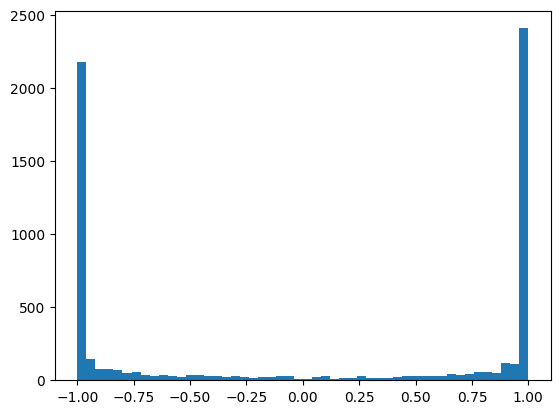

In [ ]:
plt.hist(hidden.view(-1).tolist(), 50); ## most values after tanh activation are either -1 or 1

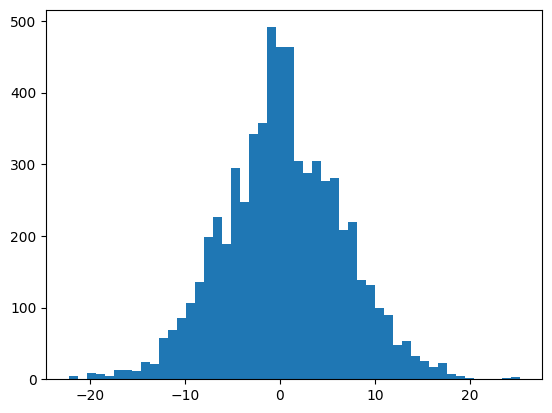

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50); ## the above is caused because the input distribution to the tanh has high variance (-20, 20)

So why is this bad?? if value of tanh is either -1/1 then the gradient.....

$(1-out.data^2)*out.grad = (1-1^2)*out.grad = 0$  ---> GRADIENT VANISHES!!


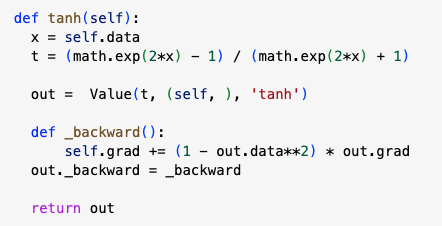

---

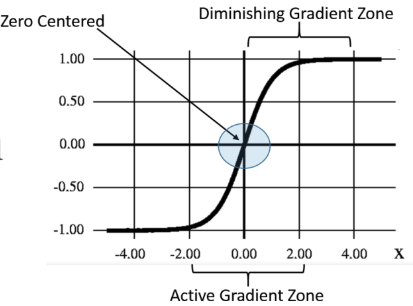


So the gradient flowing through tanh will only be quelled and never grows. The max gradient that can pass through a tanh is itself(i.e out.grad)

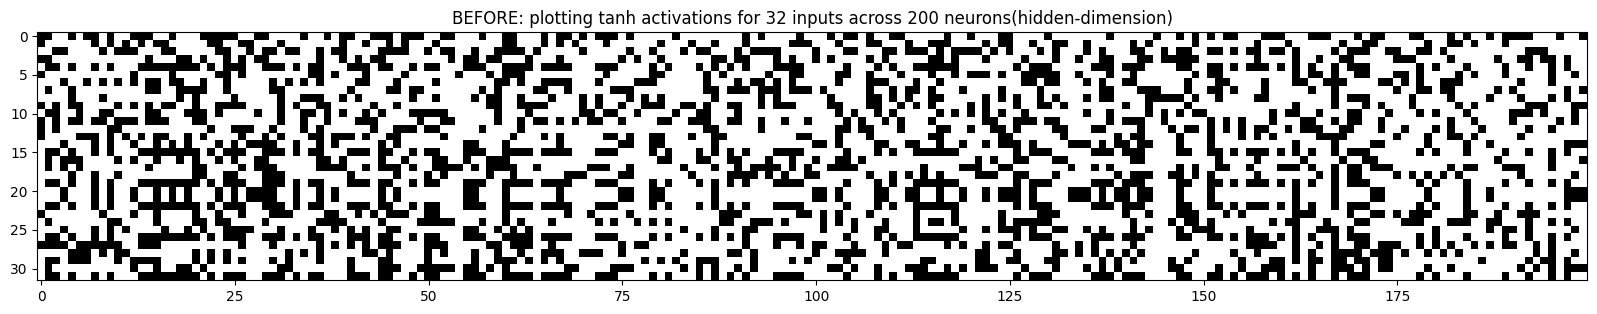

In [ ]:
plt.figure(figsize=(20,10))
plt.title('BEFORE: plotting tanh activations for 32 inputs across 200 neurons(hidden-dimension)')
plt.imshow(hidden.abs()>0.99, cmap='gray')

```Permanent brain damage```

Tracking the tanh in the "diminishing gradient region" can help us understanding if any neuron kills the gradient no matter what input it gets. Because if neuron gradient is killed, there will be no learning on the weights and biases associated with that neuron. Essentially backprop would do nothing. BAD BAD BAD

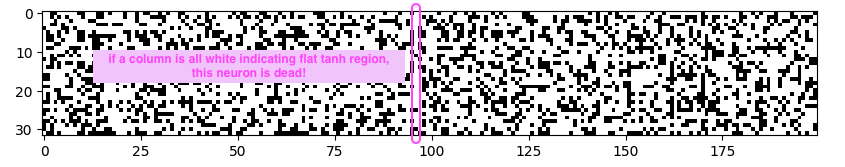

So if there are more extreme activations of tanh, there is less gradient flowing through the network, and not enough learning happening.

SO HOW TO FIX THIS??

hpreact comes from C, W1 and B1. C is uniform gaussian so nothing to fix there really. But then W1 and B1 are the ones causing the hpreact to have the high variance observed. Then, we should manipulate W1 and B1 to squash hpreact's range!

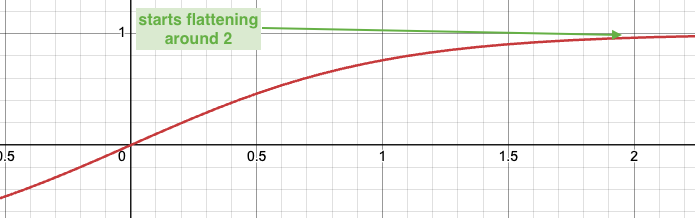

So ideally h-pre-activations should lie in range similar to (-2, 2)

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * 0.1
B1 = torch.randn(hidden_size,                            generator=g) * 0.01 # good to have some value instead of 0, to have some entropy in the network
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


11897


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1
  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())
  break

      0/ 200000:3.3069


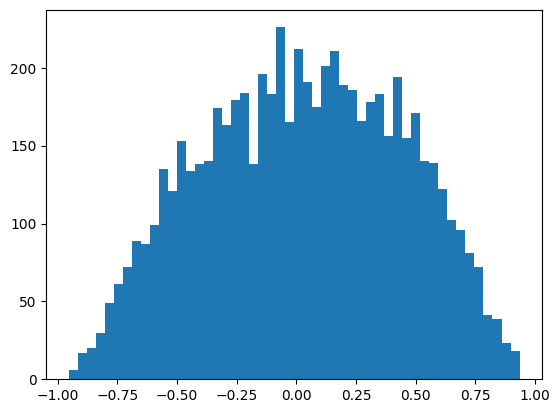

In [ ]:
plt.hist(hidden.view(-1).tolist(), 50); ## much better distributed activations

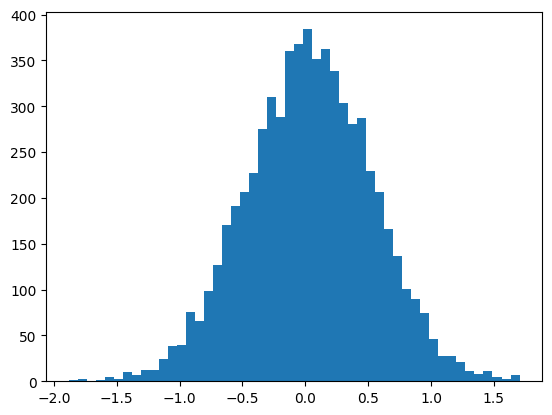

In [ ]:
plt.hist(hpreact.view(-1).tolist(), 50); ## much lower variance (-1.5, 1.5)

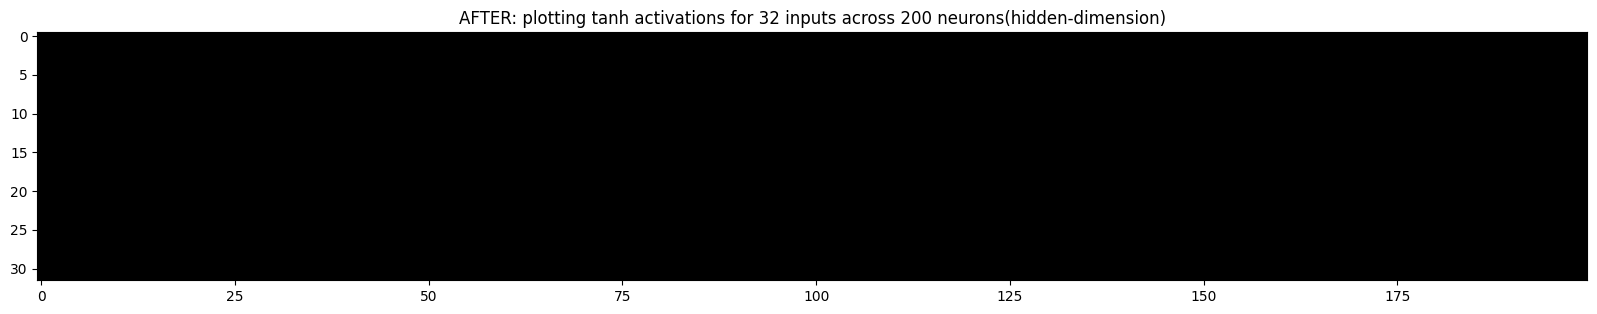

In [ ]:
plt.figure(figsize=(20,10))
plt.title('AFTER: plotting tanh activations for 32 inputs across 200 neurons(hidden-dimension)')
plt.imshow(hidden.abs()>0.99, cmap='gray')

Since there are absolutely no whites, looks like we can afford to let the values of W1 range a little higher

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * 0.2
B1 = torch.randn(hidden_size,                            generator=g) * 0.01 # good to have some value instead of 0, to have some entropy in the network
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


11897


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1
  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())
  break

      0/ 200000:3.3135


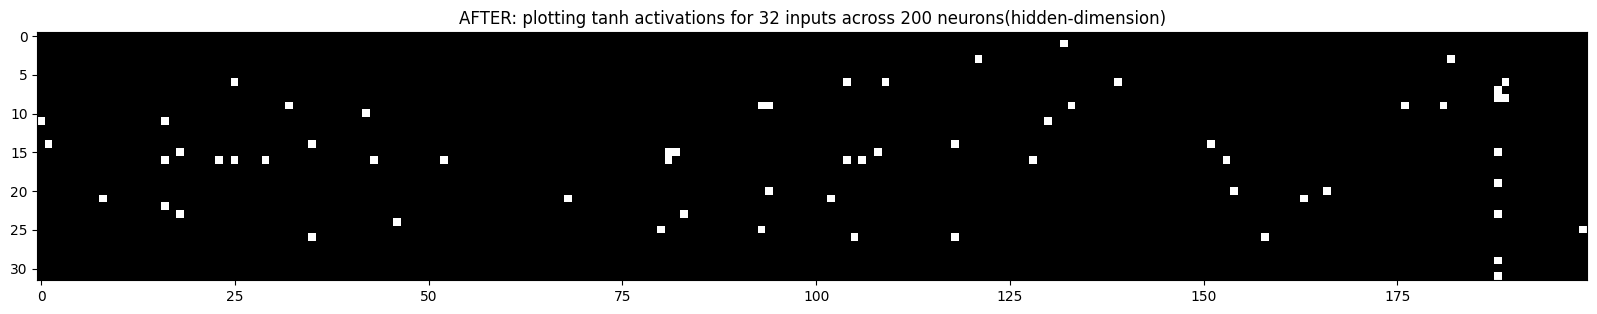

In [ ]:
plt.figure(figsize=(20,10))
plt.title('AFTER: plotting tanh activations for 32 inputs across 200 neurons(hidden-dimension)')
plt.imshow(hidden.abs()>0.99, cmap='gray')

In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1
  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.2465
  10000/ 200000:1.9043
  20000/ 200000:1.9004
  30000/ 200000:1.9465
  40000/ 200000:2.1656
  50000/ 200000:2.0071
  60000/ 200000:2.0826
  70000/ 200000:2.4228
  80000/ 200000:2.3109
  90000/ 200000:2.1167
 100000/ 200000:2.2166
 110000/ 200000:1.8038
 120000/ 200000:2.2112
 130000/ 200000:1.9618
 140000/ 200000:1.8056
 150000/ 200000:2.4102
 160000/ 200000:2.1829
 170000/ 200000:1.6967
 180000/ 200000:1.9343
 190000/ 200000:2.1057


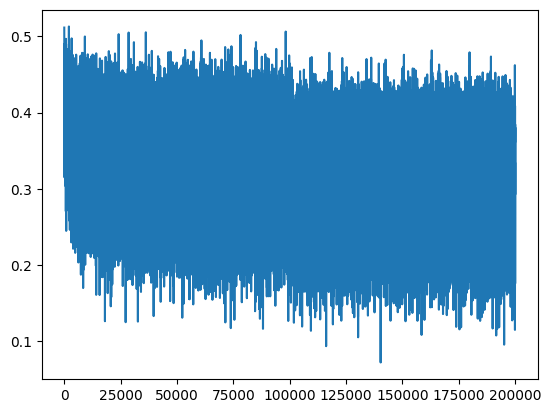

In [ ]:
plt.plot(log_loss)

In [ ]:
split_loss('train')
split_loss('val')

train 2.0357086658477783
val 2.102949380874634


## OK, all this weight manipulation makes sense, but is there a more elegant way to set the proportions??? YES!

Enter.... *KAIMING NORM*  (I swear it would make a great anime protagonist name)

tensor(0.0022) tensor(0.9964)
tensor(-0.0046) tensor(3.1919)


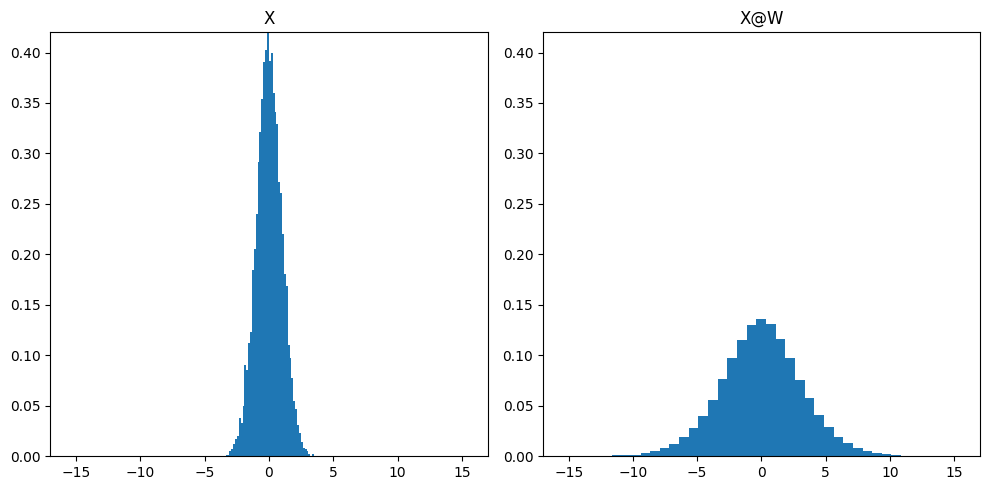

In [ ]:
# Consider the sample input processed through one layer of weights

x = torch.randn(1000, 10)
w = torch.randn(10, 200)

y = x @ w

print(x.mean(), x.std())
print(y.mean(), y.std())

fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Defining custom 'xlim' and 'ylim' values.
custom_xlim = (-17, 17)
custom_ylim = (0, 0.42)


# Setting the values for all axes.
plt.setp(axes, xlim=custom_xlim, ylim=custom_ylim)

# Plot on the first subplot
axes[0].hist(x.view(-1).tolist(), 50, density=True);
axes[0].set_title('X')
# axes[0].legend()


# Plot on the second subplot
axes[1].hist(y.view(-1).tolist(), 50, density=True);
axes[1].set_title('X@W')
# axes[1].legend()


# Adjust layout
plt.tight_layout()
plt.show()

## the std deviation increases as the input is processed more and more(multiplied by more and more things)

### ------------------------------------------ CUTESY DETOUR ------------------------------------------



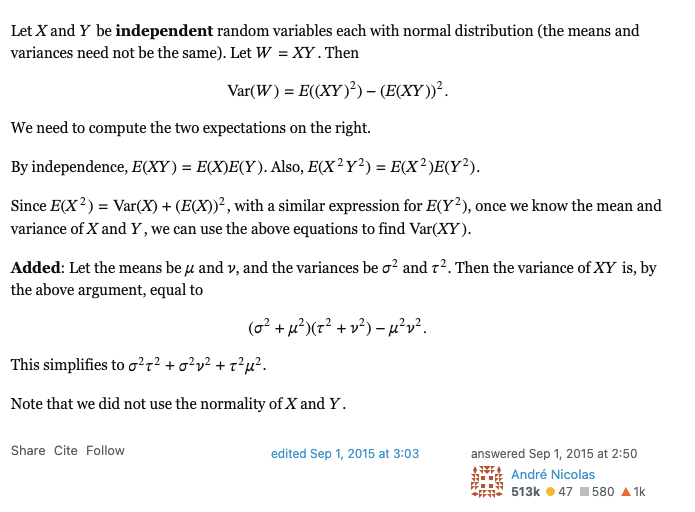

In [ ]:
x = torch.randn(10, 10)
w = torch.randn(10, 10)
t = x * w

print(x.mean(), x.std())
print(w.mean(), w.std())

print(t.mean(), t.std())
a = x.std()
b = w.std()

print((a**2*b**2 + a**2*w.mean()**2 + b**2*x.mean()**2)**0.5)

tensor(-0.0044) tensor(1.0109)
tensor(0.0653) tensor(0.9762)
tensor(0.0362) tensor(0.9933)
tensor(0.9891)


### ------------------------------------------ CUTESY DETOUR END ------------------------------------------

In [ ]:
import numpy as np
def print_deviation(x, w):
  y = x @ w
  print(x.mean(), x.std())
  print(y.mean(), y.std())

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

  # Defining custom 'xlim' and 'ylim' values.
  max_val = np.max(y.numpy())
  custom_xlim = (-max_val, max_val)
  custom_ylim = (0, 0.42)


  # Setting the values for all axes.
  plt.setp(axes, xlim=custom_xlim, ylim=custom_ylim)

  # Plot on the first subplot
  axes[0].hist(x.view(-1).tolist(), 50, density=True);
  axes[0].set_title('X')
  # axes[0].legend()

  # Plot on the second subplot
  axes[1].hist(y.view(-1).tolist(), 50, density=True);
  axes[1].set_title('X@W')
  # axes[1].legend()

  # Adjust layout
  plt.tight_layout()
  plt.show()

tensor(0.0022) tensor(0.9917)
tensor(-0.0171) tensor(15.7442)


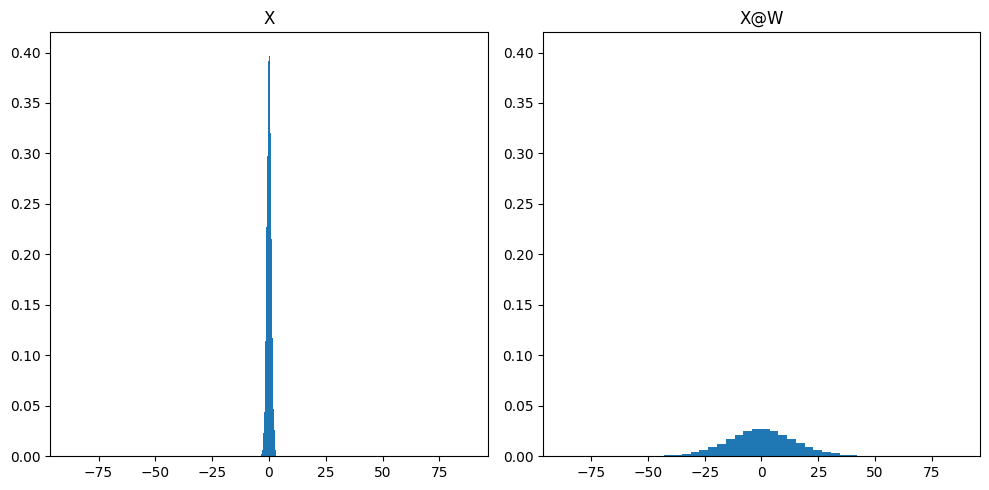

In [ ]:
## For scaled up values of w, the std deviation increases even more
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 5
print_deviation(x, w)

tensor(-0.0065) tensor(1.0020)
tensor(0.0027) tensor(1.6286)


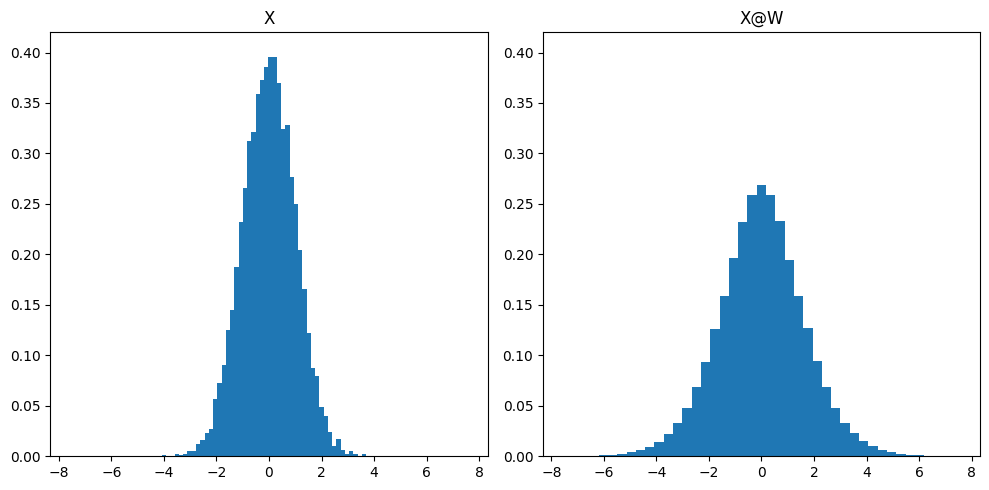

In [ ]:
## For scaled down values of w, the std deviation decreases
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * 0.5
print_deviation(x, w)

So what's the ideal setting of scaling factor to be used for w(weights).

Mathematically, $\sqrt{d_k}$ -- similar to what you studied for Transformers!!  https://www.youtube.com/watch?v=5S_o0bDJdZA

Why $\sqrt{d_k}$ https://www.youtube.com/watch?v=wi1w1ZgKM8U&t=1s


Kaiming https://pytorch.org/docs/stable/nn.init.html#torch.nn.init.kaiming_uniform_

"Kaiming init" paper: https://arxiv.org/abs/1502.01852

tensor(-0.0031) tensor(0.9941)
tensor(-0.0015) tensor(0.9949)


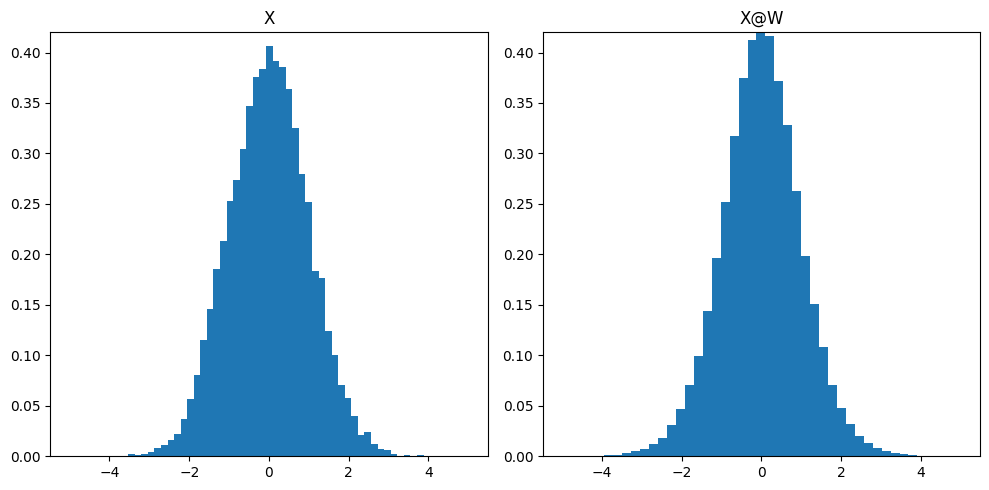

In [ ]:
## For scaled down values of w, the std deviation decreases
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 # here d_k(fan_in) is 10 kaiming
print_deviation(x, w)

**```why do we need a gain??```**

simply Kaiming norming squashes the inputs too much - so the gain is a counterforce to fight the extreme squashing. [eg. in ReLU entirety of negative half is squashed, which is countered with a gain of $\sqrt 2$ ]

In [ ]:
import numpy as np
def print_tan_squash(x, w):
  y = torch.tanh(x @ w)
  print(x.mean(), x.std())
  print(y.mean(), y.std())

  fig, axes = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

  # Plot on the first subplot
  axes[0].hist(x.view(-1).tolist(), 50, density=True);
  axes[0].set_title('X')
  # axes[0].legend()

  # Plot on the second subplot
  axes[1].hist(y.view(-1).tolist(), 50, density=True);
  axes[1].set_title('TANH(X@W)')
  # axes[1].legend()

  # Adjust layout
  plt.tight_layout()
  plt.show()

tensor(-0.0038) tensor(0.9948)
tensor(0.0027) tensor(0.8564)


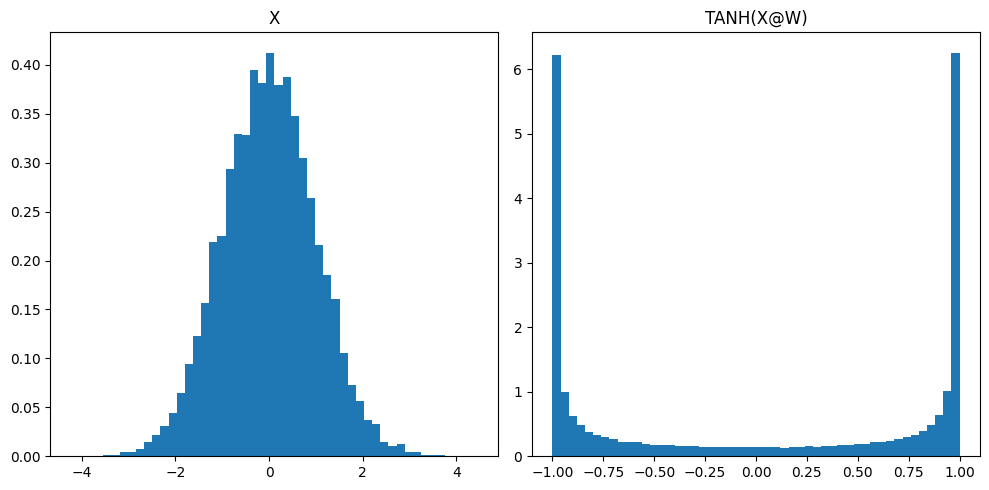

In [ ]:
## tanh without normalization - number of values at extremes is >6*2
x = torch.randn(1000, 10)
w = torch.randn(10, 200)
y = torch.tanh(x @ w)
print_tan_squash(x, w)

tensor(0.0091) tensor(0.9971)
tensor(-0.0014) tensor(0.6164)


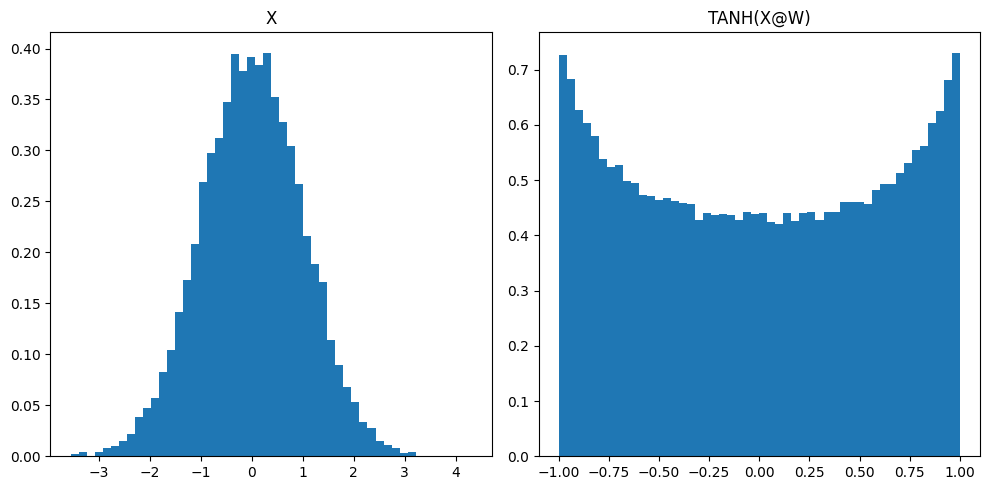

In [ ]:
## tanh with kaiming norm - number of values at extremes are almost the same as any other value
x = torch.randn(1000, 10)
w = torch.randn(10, 200) / 10**0.5 # here d_k(fan_in) is 10 kaiming
y = torch.tanh(x @ w)
print_tan_squash(x, w)

tensor(-0.0030) tensor(0.9989)
tensor(-0.0022) tensor(0.7427)


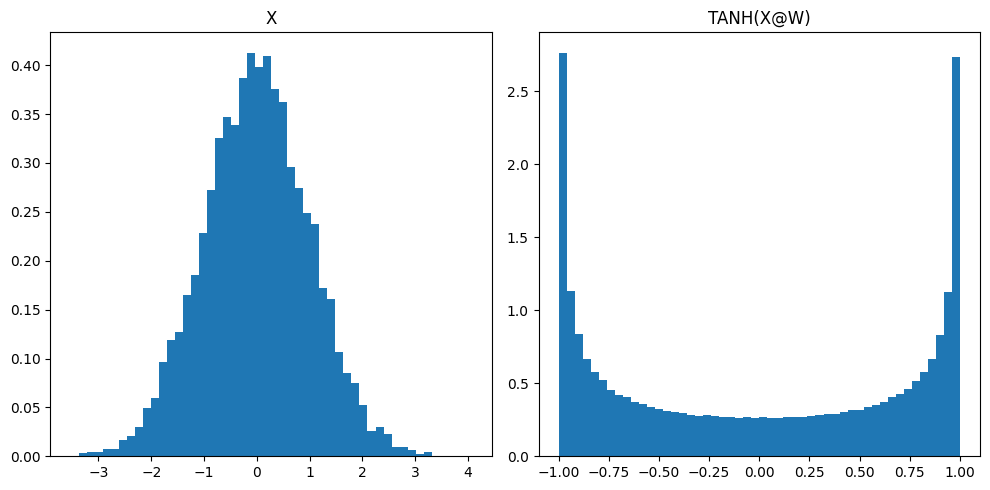

In [ ]:
## tanh with kaiming norm + gain  - there are some values at extremes now.
x = torch.randn(1000, 10)
w = torch.randn(10, 200) * (5/3) / 10**0.5 # here d_k(fan_in) is 10 kaiming

y = torch.tanh(x @ w)
print_tan_squash(x, w)

In [ ]:
# Squashing W1 using Kaiming initialization
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * (5/3) / (block_size * embed_size)**0.5 # Kaiming
B1 = torch.randn(hidden_size,                            generator=g) * 0.01 # good to have some value instead of 0, to have some entropy in the network
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


11897


In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1
  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3179
  10000/ 200000:2.1910
  20000/ 200000:2.3270
  30000/ 200000:2.5396
  40000/ 200000:1.9468
  50000/ 200000:2.3331
  60000/ 200000:2.3852
  70000/ 200000:2.1173
  80000/ 200000:2.3159
  90000/ 200000:2.2010
 100000/ 200000:1.8591
 110000/ 200000:2.0881
 120000/ 200000:1.9389
 130000/ 200000:2.3913
 140000/ 200000:2.0949
 150000/ 200000:2.1458
 160000/ 200000:1.7824
 170000/ 200000:1.7249
 180000/ 200000:1.9752
 190000/ 200000:1.8614


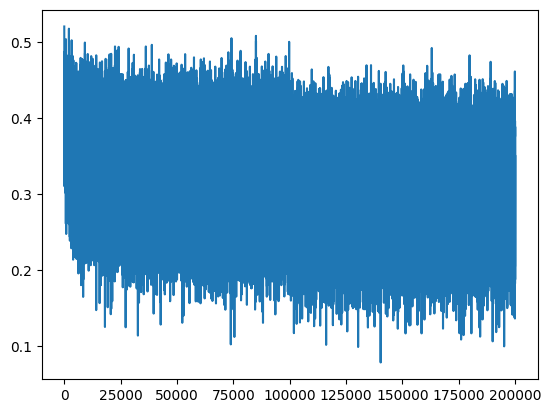

In [ ]:
plt.plot(log_loss)

In [ ]:
split_loss('train')
split_loss('val')

train 2.0376641750335693
val 2.106989622116089


Over time - such manual settings of the weight scales is no longer needed.
This happened because of improvements in optimization and regularization techniques. One such technique is

# Batch Normalization

BatchNorm paper: https://arxiv.org/abs/1502.03167

Insight: until now you pre-treated the weights by scaling them down such that the generated hidden state has a normal distribution, why not just do this as a post-treatment?? that is, let the hidden states be generated per usual and then normalize them in post!

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * 0.2
B1 = torch.randn(hidden_size,                            generator=g) * 0.01 # good to have some value instead of 0, to have some entropy in the network
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0

parameters = [C, W1, B1, W2, B2]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


11897


In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1

  ##########  NEW  ##########
  hpreact = (hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True)
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3147
  10000/ 200000:2.1426
  20000/ 200000:2.3128
  30000/ 200000:2.4206
  40000/ 200000:1.9814
  50000/ 200000:2.3441
  60000/ 200000:2.5317
  70000/ 200000:2.0418
  80000/ 200000:2.3075
  90000/ 200000:2.1127
 100000/ 200000:1.9335
 110000/ 200000:2.3863
 120000/ 200000:1.9474
 130000/ 200000:2.4764
 140000/ 200000:2.3550
 150000/ 200000:2.2926
 160000/ 200000:2.0620
 170000/ 200000:1.8535
 180000/ 200000:1.9758
 190000/ 200000:1.8365


In [ ]:
split_loss('train')
split_loss('val')

train 2.760587215423584
val 2.781526565551758


Well this is bad! Duh yaaa, because the weights are always forced to be uniform distributed. They should have the freedom to move whichever way the data tells them to - POCAHONTAS that shiz!

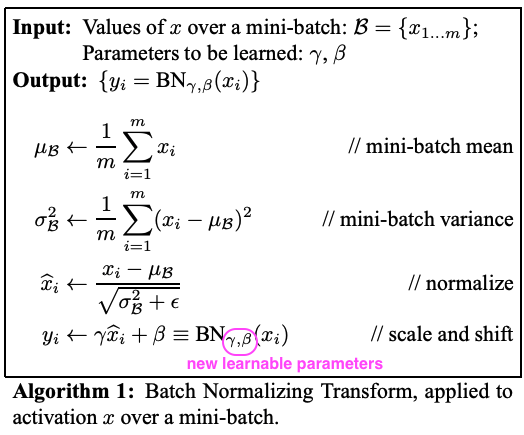

In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * 0.2
B1 = torch.randn(hidden_size,                            generator=g) * 0.01 # good to have some value instead of 0, to have some entropy in the network
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0

##########  NEW  ##########
bnscale = torch.ones((1, hidden_size))
bnshift = torch.zeros((1, hidden_size))

parameters = [C, W1, B1, W2, B2, bnscale, bnshift]
##########  NEW  ##########

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True



12297


In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True)) + bnshift
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3147
  10000/ 200000:2.1341
  20000/ 200000:2.3173
  30000/ 200000:2.4115
  40000/ 200000:2.0124
  50000/ 200000:2.3003
  60000/ 200000:2.4708
  70000/ 200000:2.1208
  80000/ 200000:2.3562
  90000/ 200000:2.1095
 100000/ 200000:1.9329
 110000/ 200000:2.3919
 120000/ 200000:1.9794
 130000/ 200000:2.4764
 140000/ 200000:2.3703
 150000/ 200000:2.3098
 160000/ 200000:2.0003
 170000/ 200000:1.8345
 180000/ 200000:2.0355
 190000/ 200000:1.8853


In [ ]:
# decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hpreact = embed.view(x.shape[0], -1)@ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True)) + bnshift
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact) # (N, hidden_size)

  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0620572566986084
val 2.1022262573242188


Testing w/o kaiming to see if batch-norm does obviate the need to customize weight scaling

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g)
B1 = torch.randn(hidden_size,                            generator=g)
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0

##########  NEW  ##########
bnscale = torch.ones((1, hidden_size))
bnshift = torch.zeros((1, hidden_size))

parameters = [C, W1, B1, W2, B2, bnscale, bnshift]
##########  NEW  ##########

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True



12297


In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True)) + bnshift
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3147
  10000/ 200000:2.2394
  20000/ 200000:2.3971
  30000/ 200000:2.4796
  40000/ 200000:1.9593
  50000/ 200000:2.4193
  60000/ 200000:2.4371
  70000/ 200000:2.0502
  80000/ 200000:2.3512
  90000/ 200000:2.1712
 100000/ 200000:1.9607
 110000/ 200000:2.3153
 120000/ 200000:2.0002
 130000/ 200000:2.5127
 140000/ 200000:2.3774
 150000/ 200000:2.2193
 160000/ 200000:1.9669
 170000/ 200000:1.8630
 180000/ 200000:2.1262
 190000/ 200000:1.8570


In [ ]:
# decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hpreact = embed.view(x.shape[0], -1)@ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - hpreact.mean(dim=0, keepdim=True)) / hpreact.std(dim=0, keepdim=True)) + bnshift
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact) # (N, hidden_size)

  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1120095252990723
val 2.136747360229492


Guess not so much, oh well 🤷

People typically do not like batch norm as much, since it makes 1 neuron (which is essentially only a single dimension that would've been affected by one input sample at a time) be effected by all input samples in the batch

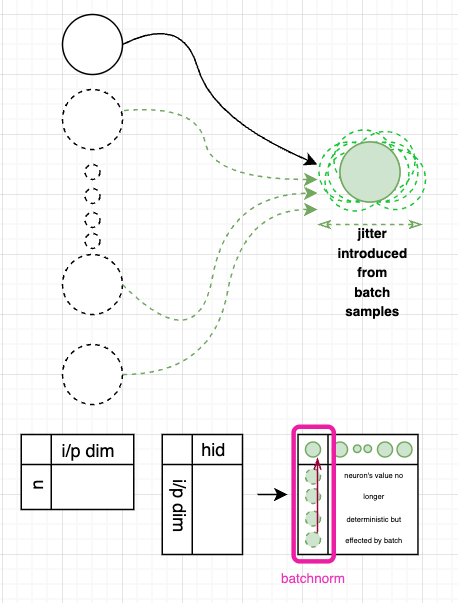


(n x i/p) @ (i/p x hid) = n*hid

say hidden dim are 100 - then the first hidden neuron would have an output corresponding to each 'n' input.

Then we take softmax over every row of hidden across 100.
Then select prob corresponding to label y for each input

In this scenario, the relationship between input x [1 of n] to its label y[1 of n] is deterministic.

The minute you introduce batchnorm, the mean of the batch also effects the final probability of each sample. This is the JITTER

While this feels like a bug, it acts as a regularizer in training (avoiding any neuron from being too specific)

## STATIC TRAIN STATS

In [ ]:
with torch.no_grad():
  embed = C[xTr]
  hpreact = embed.view(xTr.shape[0], -1)@ W1 + B1

  bnmean = hpreact.mean(dim=0, keepdim=True)
  bnstd = hpreact.std(dim=0, keepdim=True)

# decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hpreact = embed.view(x.shape[0], -1)@ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - bnmean) / bnstd) + bnshift  # so even at validation and test time, train batch stats used to normalize
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact) # (N, hidden_size)

  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.1120095252990723
val 2.1367697715759277


## RUNNING STATS

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * (5/3) / (block_size * embed_size)**0.5 # Kaiming
B1 = torch.randn(hidden_size,                            generator=g) * 0.01
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0


bnscale = torch.ones((1, hidden_size))
bnshift = torch.zeros((1, hidden_size))

##########  NEW  ##########
bnmean_running = torch.zeros((1, hidden_size))
bnstd_running = torch.ones((1, hidden_size))
##########  NEW  ##########

parameters = [C, W1, B1, W2, B2, bnscale, bnshift]
print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True



12297


## TINY DETOUR to check that bias gets nulled out by the norm shift

In [ ]:
B1.grad is None

True

In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  dot = embed.view(xTr[ind].shape[0], -1) @ W1
  hpreact = dot  + B1
  hpreact2 = dot

  print(B1.grad is None)

  ##########  NEW  ##########
  bnmeani = hpreact.mean(dim=0, keepdim=True)
  bnmeani2 = hpreact2.mean(dim=0, keepdim=True)
  bnstdi = hpreact.std(dim=0, keepdim=True)
  ##########  NEW  ##########

  print("Means with and without bias")
  print(torch.allclose((hpreact - bnmeani), (hpreact2 - bnmeani2), atol=1e-4))

  print((hpreact - bnmeani) == (hpreact2 - bnmeani2))
  print(hpreact - bnmeani)
  print(hpreact2 - bnmeani2)
  break

True
Means with and without bias
True
tensor([[ True,  True,  True,  ...,  True,  True, False],
        [False, False, False,  ..., False,  True,  True],
        [ True,  True, False,  ...,  True,  True,  True],
        ...,
        [ True, False,  True,  ...,  True, False,  True],
        [ True, False, False,  ...,  True,  True,  True],
        [ True, False, False,  ..., False,  True,  True]])
tensor([[ 0.3413, -1.2660, -1.1943,  ...,  0.5626, -0.3631, -0.8326],
        [-1.9714,  0.8048,  0.7132,  ...,  0.2030,  1.5470,  1.3614],
        [-0.6423,  1.1370,  0.3148,  ...,  0.6157,  2.0789,  1.7242],
        ...,
        [ 0.6685,  0.0514, -0.3301,  ..., -0.5152, -0.5393,  0.5099],
        [ 1.5672, -0.4621,  2.9112,  ..., -0.8668,  0.6393,  2.4968],
        [-2.1593,  0.0681,  0.3265,  ...,  0.1369,  1.1632,  1.5609]],
       grad_fn=<SubBackward0>)
tensor([[ 0.3413, -1.2660, -1.1943,  ...,  0.5626, -0.3631, -0.8326],
        [-1.9714,  0.8048,  0.7132,  ...,  0.2030,  1.5470,  1.36

In [ ]:
(hpreact - bnmeani)[0][0].item(), (hpreact2 - bnmeani2)[0][0].item() ## false because of floating point precision but they are the same!

(0.34134894609451294, 0.34134894609451294)

## TINY DETOUR END

back to check how running mean is equivalent to a post-computed mean

In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1   + B1
  ##########  NEW  ##########
  bnmeani = hpreact.mean(dim=0, keepdim=True)
  bnstdi = hpreact.std(dim=0, keepdim=True)
  ##########  NEW  ##########

  hpreact = (bnscale*(hpreact - bnmeani) / bnstdi) + bnshift

  #########  NEW  ##########
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi
  #########  NEW  ##########

  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3203
  10000/ 200000:2.4904
  20000/ 200000:2.6501
  30000/ 200000:2.0596
  40000/ 200000:2.1189
  50000/ 200000:2.0740
  60000/ 200000:2.1963
  70000/ 200000:2.3516
  80000/ 200000:2.2640
  90000/ 200000:2.2557
 100000/ 200000:1.9906
 110000/ 200000:2.5457
 120000/ 200000:2.0587
 130000/ 200000:2.2953
 140000/ 200000:2.1832
 150000/ 200000:2.2340
 160000/ 200000:2.0256
 170000/ 200000:2.4514
 180000/ 200000:2.3442
 190000/ 200000:2.1919


In [ ]:
B1.grad[:10] ## some gradient still accumulated because of floating point difference

TypeError: 'NoneType' object is not subscriptable

In [ ]:
with torch.no_grad():
  embed = C[xTr]
  hpreact = embed.view(xTr.shape[0], -1)@ W1 + B1

  bnmean = hpreact.mean(dim=0, keepdim=True)
  bnstd = hpreact.std(dim=0, keepdim=True)

In [ ]:
bnmean_running

tensor([[-2.3827,  0.6625, -0.9169,  1.0123,  1.1172,  1.0988,  1.7462, -2.1008,
          0.5567,  1.4061, -1.5605, -2.7572, -0.4807, -0.1576, -0.1004, -1.1379,
          0.6693, -2.6214, -0.1723,  1.6251, -0.7485, -0.3233,  0.0452,  0.5820,
          1.1284,  0.3649,  2.0366,  0.5780,  0.8205,  1.7659, -0.3439, -0.8333,
         -0.0831, -0.5183, -0.4011, -1.1031, -0.1103,  0.3365, -0.4956,  1.0026,
         -0.3961, -1.3248, -0.2725, -0.2098,  0.7676,  0.7095,  2.0717, -0.7825,
          2.3778,  1.8705,  0.8384,  0.3039,  1.8765,  0.4628,  0.6215, -1.9049,
         -0.0352,  0.4182,  1.3888, -0.9013, -0.4660,  1.1645,  0.5681,  0.6014,
          1.5889,  1.1375, -1.0280,  2.1529, -0.6705,  0.0490, -0.2058, -0.4730,
          0.9892, -1.0247, -2.9870,  0.6762,  1.4601, -0.1611,  0.0991,  0.5231,
          0.2352,  1.2731,  2.0206,  0.6484,  0.0630, -0.0874, -1.6973,  0.2893,
          2.2458, -0.0310, -0.6568,  1.4085, -0.7842, -1.2171, -1.0528,  0.2223,
          0.1734, -0.3667,  

In [ ]:
bnmean

tensor([[-2.3635,  0.6516, -0.9296,  1.0131,  1.1148,  1.1065,  1.7500, -2.0865,
          0.5698,  1.4275, -1.5500, -2.7530, -0.4690, -0.1472, -0.1063, -1.1543,
          0.6656, -2.6034, -0.1506,  1.6345, -0.7456, -0.3437,  0.0470,  0.5823,
          1.1276,  0.3645,  2.0326,  0.5844,  0.8224,  1.7610, -0.3324, -0.8291,
         -0.0850, -0.5156, -0.3988, -1.1034, -0.1102,  0.3484, -0.4990,  0.9976,
         -0.3881, -1.3013, -0.2705, -0.2132,  0.7647,  0.7007,  2.0737, -0.7674,
          2.3828,  1.8815,  0.8523,  0.3098,  1.8865,  0.4628,  0.6292, -1.9025,
         -0.0333,  0.4174,  1.3721, -0.9021, -0.4495,  1.1715,  0.5747,  0.6060,
          1.5892,  1.1536, -1.0216,  2.1587, -0.6779,  0.0361, -0.1987, -0.4753,
          1.0020, -1.0565, -2.9942,  0.6890,  1.4534, -0.1633,  0.0985,  0.5329,
          0.2373,  1.2848,  2.0482,  0.6390,  0.0567, -0.0821, -1.6929,  0.2850,
          2.2502, -0.0412, -0.6559,  1.3990, -0.7817, -1.2099, -1.0455,  0.2252,
          0.1931, -0.3624,  

In [ ]:
## CHECK IF RUNNING VALUE SAME AS POST CALCULATED VALUE

torch.allclose(bnmean_running,bnmean,atol=0.1)

# THEY ARE - so proved that keeping a running mean instead of a post calculation of mean is equivalent

True

In [ ]:
# decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hpreact = embed.view(x.shape[0], -1)@ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - bnmean_running) / bnstd_running) + bnshift  # so even at validation and test time, train batch stats used to normalize
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact) # (N, hidden_size)

  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.066436290740967
val 2.105018138885498


## FINALLY, since the bias gets cancelled out after a mean subtraction, we can eliminate bias from the network

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)
W1 = torch.randn((block_size * embed_size, hidden_size), generator=g) * (5/3) / (block_size * embed_size)**0.5 # Kaiming
# B1 = torch.randn(hidden_size,                            generator=g) * 0.01
W2 = torch.randn((hidden_size, vocab_size),              generator=g) * 0.01
B2 = torch.randn(vocab_size,                             generator=g) * 0


bnscale = torch.ones((1, hidden_size))
bnshift = torch.zeros((1, hidden_size))

##########  NEW  ##########
bnmean_running = torch.zeros((1, hidden_size))
bnstd_running = torch.ones((1, hidden_size))
##########  NEW  ##########

# parameters = [C, W1, B1, W2, B2, bnscale, bnshift]
parameters = [C, W1, W2, B2, bnscale, bnshift]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True



12097


In [ ]:
# FULL TRAINING
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  # linear layer
  hpreact = embed.view(xTr[ind].shape[0], -1) @ W1

  #batch-normalization
  bnmeani = hpreact.mean(dim=0, keepdim=True)
  bnstdi = hpreact.std(dim=0, keepdim=True)
  hpreact = (bnscale*(hpreact - bnmeani) / bnstdi) + bnshift
  with torch.no_grad():
    bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani ## 0.001 is called the momentum in BatchNorm1d https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html
    bnstd_running = 0.999 * bnstd_running + 0.001 * bnstdi

  # tanh non-linearity
  hidden = torch.tanh(hpreact)
  logits = hidden @ W2 + B2
  loss = F.cross_entropy(logits, yTr[ind])

  # backward-pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

      0/ 200000:3.3239
  10000/ 200000:2.0322
  20000/ 200000:2.5675
  30000/ 200000:2.0125
  40000/ 200000:2.2446
  50000/ 200000:1.8897
  60000/ 200000:2.0785
  70000/ 200000:2.3681
  80000/ 200000:2.2918
  90000/ 200000:2.0238
 100000/ 200000:2.3673
 110000/ 200000:2.3132
 120000/ 200000:1.6414
 130000/ 200000:1.9311
 140000/ 200000:2.2231
 150000/ 200000:2.0027
 160000/ 200000:2.0997
 170000/ 200000:2.4949
 180000/ 200000:2.0199
 190000/ 200000:2.1707


In [ ]:
## decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hpreact = embed.view(x.shape[0], -1)@ W1
  hpreact = (bnscale*(hpreact - bnmean_running) / bnstd_running) + bnshift  # so even at validation and test time, train batch stats used to normalize

  hidden = torch.tanh(hpreact) # (N, hidden_size)

  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

train 2.0674147605895996
val 2.1056840419769287


### DETOUR: how to decide value of momentum in BatchNorm1d https://pytorch.org/docs/stable/generated/torch.nn.BatchNorm1d.html




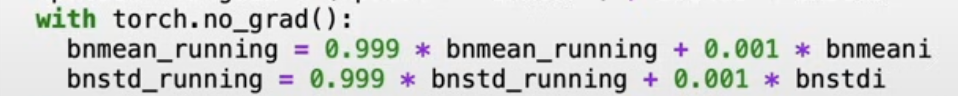

if batch_size is large, the current mean is a good estimate of the total mean, and hence there won't be as much of an issue if this mean were to be added to the running mean in good proportion. Here, momentum can be as high as 0.1

if batch_size is small, like in our case, the current mean is not a good estimate of total mean, so it shouldn't contribute to the running mean a lot. So, momentum is low 0.001



```
torch.nn.BatchNorm1d(
  num_features,
  eps=1e-05,
  momentum=0.1, ---> for incorporating current mean
  affine=True,  ---> to have learnable γ and β  
  track_running_stats=True, ---> to maintain running mean and std
  device=None,
  dtype=None
  )
```

# PYTORCH-IFY!

In [ ]:
class Linear: #### MINOR MISTAKE THAT GENERATOR g IS NOT PASSED AS ARGUMENT DURING INITIALIZATION

  def __init__(self, fan_in, fan_out, bias=True):
    self.weight = torch.randn((fan_in, fan_out), generator=g)/fan_in**0.5   # remember it is fan_in coz variance dependent on dimensionality of the input this weight receives
    self.bias = torch.zeros(fan_out) if bias else None

  def __call__(self, x):
    self.out = x @ self.weight
    if self.bias is not None:
      self.out += self.bias
    return self.out

  def parameters(self):
    return [self.weight] + ([] if self.bias is None else [self.bias]) # [self.weight] converts tensor weights to list

In [ ]:
class BatchNorm1d:

  def __init__(self, dim, eps= 1e-05, momentum=0.1):

    self.eps = eps
    self.momentum = momentum
    self.training = True

    # learnable parameters
    self.gamma = torch.ones(dim)
    self.beta = torch.zeros(dim)

    # stats
    self.running_mean = torch.zeros(dim)
    self.running_var = torch.ones(dim)

  def __call__(self, x):

    if self.training:
      bmean = x.mean(0, keepdim=True) # batch_mean
      bvar = x.var(0, keepdim=True)   # batch_var
    else:
      bmean = self.running_mean
      bvar = self.running_var

    xhat = (x - bmean)/ torch.sqrt(bvar+self.eps)
    self.out = self.gamma * xhat + self.beta

    if self.training:
      with torch.no_grad():
        self.running_mean = (1 - self.momentum)*self.running_mean + self.momentum * bmean
        self.running_var = (1 - self.momentum)*self.running_var + self.momentum * bvar

    return self.out

  def parameters(self):
    return [self.gamma, self.beta]


In [ ]:
class Tanh:
  def __call__(self, x):
    self.out = torch.tanh(x)
    return self.out

  def parameters(self):
    return []

In [ ]:
# Squashing W_last and B_last and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  break

      0/ 200000:3.2962


## Visualize Activation Histograms

layer 1 (Tanh): mean -0.02, std 0.75, saturation 20.25%
layer 3 (Tanh): mean -0.00, std 0.69, saturation 8.38%
layer 5 (Tanh): mean 0.00, std 0.67, saturation 6.62%
layer 7 (Tanh): mean -0.01, std 0.66, saturation 5.47%
layer 9 (Tanh): mean -0.02, std 0.66, saturation 6.12%


Text(0.5, 1.0, 'activation distribution')

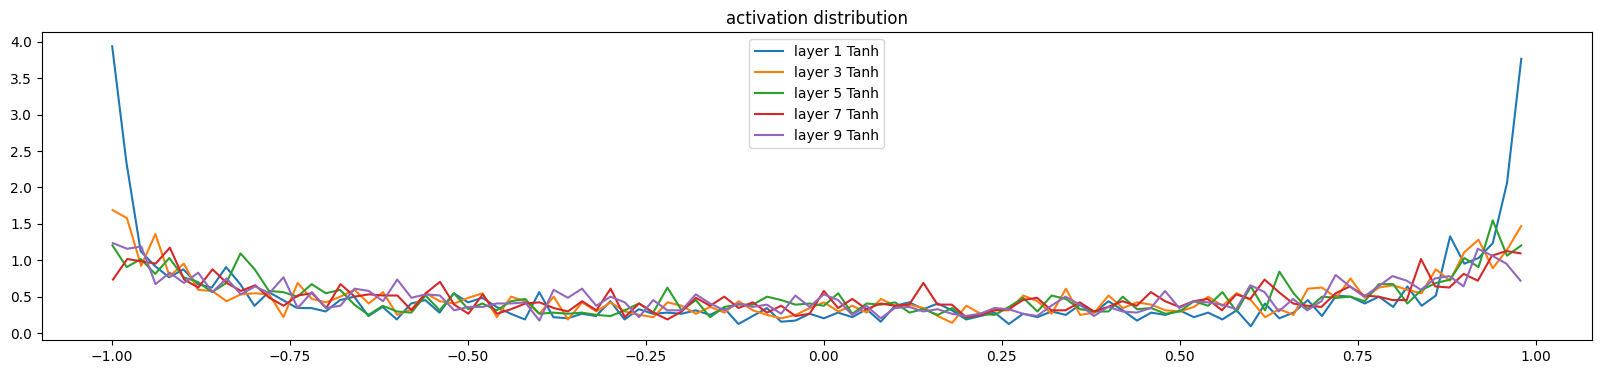

In [ ]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%')
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('activation distribution')

hx are the bins [a,b)

so for say 5 value partitions - we get 4 bins --> 1-2, 2-3, 3-4, 4-5

hence the hx[:-1]

In [ ]:
len(hx), len(hy)

(101, 100)

In [ ]:
for x, y in zip(hx[:10], hy[:10]):
  print(f"{x.item():.2f}, {y.item():.2f}")

-1.00, 1.24
-0.98, 1.16
-0.96, 1.19
-0.94, 0.67
-0.92, 0.83
-0.90, 0.69
-0.88, 0.83
-0.86, 0.56
-0.84, 0.75
-0.82, 0.53


layer 1 (Tanh): mean +0.000010, std 4.205588e-04
layer 3 (Tanh): mean -0.000003, std 3.991179e-04
layer 5 (Tanh): mean +0.000003, std 3.743020e-04
layer 7 (Tanh): mean +0.000015, std 3.290473e-04
layer 9 (Tanh): mean -0.000014, std 3.054035e-04


Text(0.5, 1.0, 'gradient distribution')

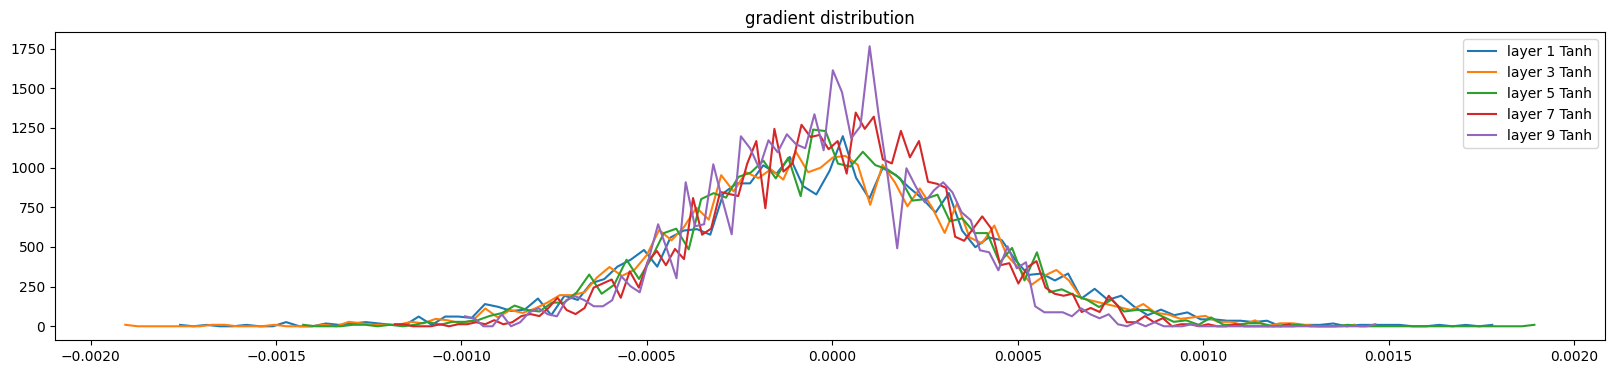

In [ ]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('gradient distribution')

In [ ]:
hx.detach().numpy() # 101 values??

array([-9.9047471e-04, -9.6567877e-04, -9.4088283e-04, -9.1608689e-04,
       -8.9129095e-04, -8.6649501e-04, -8.4169913e-04, -8.1690319e-04,
       -7.9210725e-04, -7.6731131e-04, -7.4251537e-04, -7.1771943e-04,
       -6.9292350e-04, -6.6812756e-04, -6.4333162e-04, -6.1853568e-04,
       -5.9373979e-04, -5.6894385e-04, -5.4414792e-04, -5.1935198e-04,
       -4.9455604e-04, -4.6976010e-04, -4.4496416e-04, -4.2016822e-04,
       -3.9537228e-04, -3.7057637e-04, -3.4578043e-04, -3.2098449e-04,
       -2.9618855e-04, -2.7139261e-04, -2.4659670e-04, -2.2180076e-04,
       -1.9700482e-04, -1.7220888e-04, -1.4741295e-04, -1.2261701e-04,
       -9.7821081e-05, -7.3025149e-05, -4.8229213e-05, -2.3433278e-05,
        1.3626559e-06,  2.6158590e-05,  5.0954524e-05,  7.5750460e-05,
        1.0054639e-04,  1.2534233e-04,  1.5013826e-04,  1.7493419e-04,
        1.9973013e-04,  2.2452607e-04,  2.4932207e-04,  2.7411801e-04,
        2.9891395e-04,  3.2370989e-04,  3.4850583e-04,  3.7330174e-04,
      

In [ ]:
hy.detach().numpy() ## 100 values??

array([  63.01435 ,   50.41148 ,    0.      ,    0.      ,   75.61722 ,
          0.      ,   25.20574 ,   88.22009 ,  113.425835,   75.61722 ,
         63.01435 ,  163.8373  ,  189.04306 ,  163.8373  ,  126.0287  ,
        126.029   ,  163.8373  ,  315.07175 ,  252.0574  ,  214.2488  ,
        428.4976  ,  642.74634 ,  478.90906 ,  302.46887 ,  907.4077  ,
        630.1435  ,  642.74634 , 1020.83246 ,  793.9808  ,  579.7327  ,
       1197.2726  , 1121.6554  ,  995.6268  , 1172.0676  , 1096.4497  ,
       1209.8759  , 1146.8616  , 1121.6555  , 1335.9044  , 1109.0527  ,
       1613.1676  , 1474.536   , 1184.6699  , 1260.2874  , 1764.4022  ,
       1323.3013  ,  932.6129  ,  491.5119  ,  995.6268  ,  882.1988  ,
        781.3779  ,  856.9952  ,  907.4067  ,  844.3923  ,  718.36444 ,
        667.9521  ,  478.90906 ,  466.30618 ,  352.88037 ,  504.1148  ,
        365.48322 ,  403.29184 ,  126.029   ,   88.22009 ,   88.22009 ,
         88.22009 ,   63.01435 ,  113.425835,   75.61722 ,   50.

### If we do not set the gain of 5/3 explicitly and instead have a very low gain

In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 0.5#(5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  break

      0/ 200000:3.2960


layer 1 (Tanh): mean -0.01, std 0.41, saturation 0.00%
layer 3 (Tanh): mean -0.00, std 0.20, saturation 0.00%
layer 5 (Tanh): mean 0.00, std 0.10, saturation 0.00%
layer 7 (Tanh): mean 0.00, std 0.05, saturation 0.00%
layer 9 (Tanh): mean -0.00, std 0.02, saturation 0.00%


Text(0.5, 1.0, 'activation distribution')

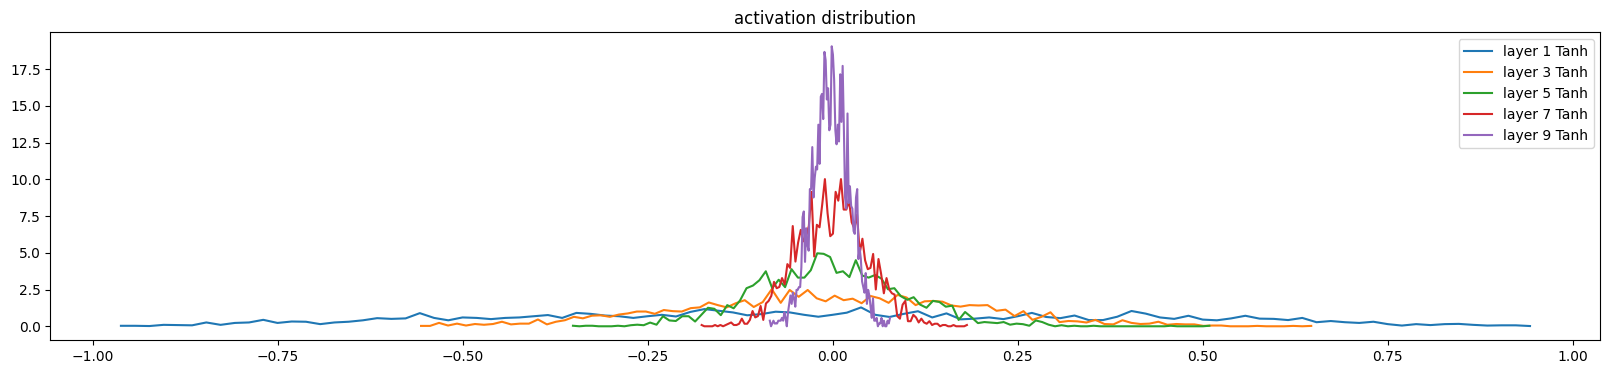

In [ ]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%') # recall, saturation is the percentage of white grids
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('activation distribution')

layer 1 (Tanh): mean +0.000000, std 1.892402e-05
layer 3 (Tanh): mean -0.000001, std 3.943546e-05
layer 5 (Tanh): mean +0.000004, std 8.035369e-05
layer 7 (Tanh): mean +0.000009, std 1.561152e-04
layer 9 (Tanh): mean -0.000014, std 3.053498e-04


Text(0.5, 1.0, 'gradient distribution')

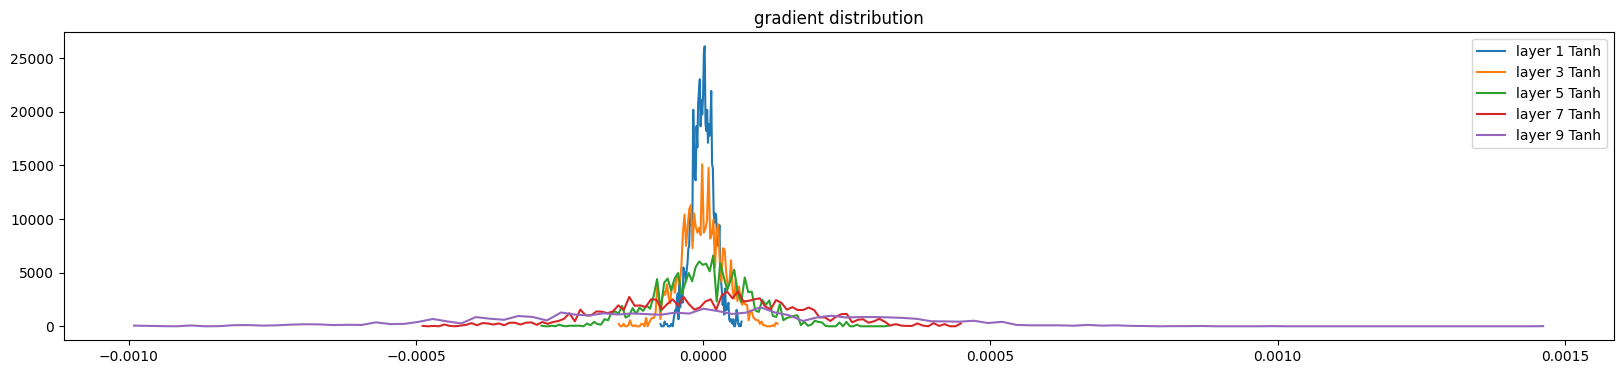

In [ ]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('gradient distribution')

Technically if we look at gradients passing backwards - this looks more like vanishing gradients situation.



*   EFFECT ON ACTIVATION:\
    So without gain, the saturation concentrates to 0. That means all gradients
    coming out of tanh are in the active gradient region.
    The blue 1st layer has a good distribution of activations, but as we process through the subsequent tanh layers, the distribution is becoming more and more biased towards the center i.e. 0.

    Recall, that a zero value of tanh implies $(1-0^2)*grad$ i.e. a gradient pass through. So nothing about the tanh activation itself AFFECTS the passing gradient. We don't want this.

    We also know by the POCAHONTAS principle, there needs to be degree of freedom in the model learning. To bring some freedom back into the network and eliminate bias, we need the gain of 5/3.

*   EFFECT ON GRADIENT:

    As the activation saturates to 0, making tanh simply a gradient passthrough, any value of the gradient simply passes back-through, hence the range of the gradients is larger. So within the same layer, different neurons would have different weight updates owing to the varying gradient scale across the layer.

    Gradients shrink down to a concentrated 0 everywhere from layer 9 to layer 1. As we go back from layer 9 to layer 1, the variance of values of activation becomes smaller, and becomes more and more concentrated at 0. So essentially most values are the same (0 +/- constant) - so there is no slope left with such low variance. FLAT region of mostly same values.
    

### For really high scaling of w

In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= 4 #(5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  break

      0/ 200000:3.2732


layer 1 (Tanh): mean -0.03, std 0.89, saturation 58.53%
layer 3 (Tanh): mean 0.00, std 0.88, saturation 54.31%
layer 5 (Tanh): mean -0.01, std 0.89, saturation 56.38%
layer 7 (Tanh): mean -0.02, std 0.89, saturation 57.84%
layer 9 (Tanh): mean -0.03, std 0.88, saturation 56.75%


Text(0.5, 1.0, 'activation distribution')

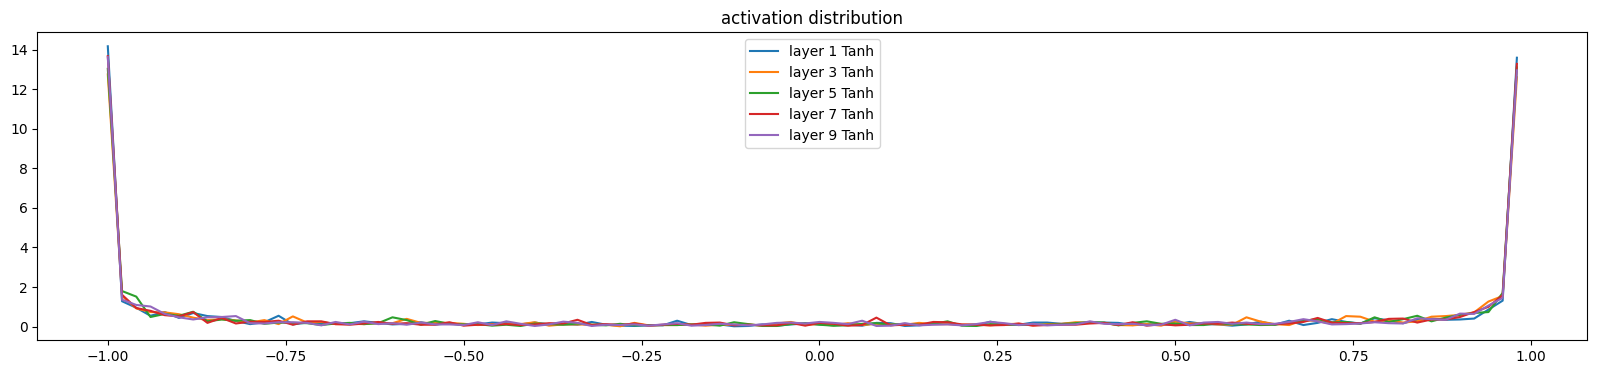

In [ ]:
# we're back to the extreme gradients
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%') # recall, saturation is the percentage of white grids
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('activation distribution')

layer 1 (Tanh): mean -0.000026, std 1.699922e-03
layer 3 (Tanh): mean +0.000020, std 1.081249e-03
layer 5 (Tanh): mean +0.000011, std 7.080198e-04
layer 7 (Tanh): mean +0.000015, std 4.596927e-04
layer 9 (Tanh): mean -0.000014, std 3.050013e-04


Text(0.5, 1.0, 'gradient distribution')

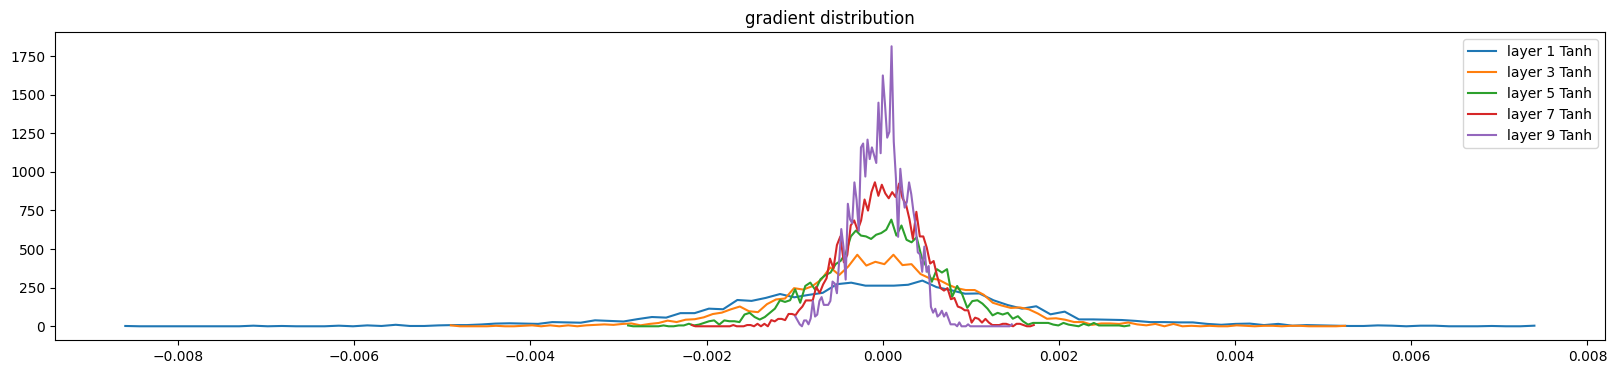

In [ ]:
# we're back to the extreme gradients
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('gradient distribution')

Ideally, we want as much symmetry as possible in the gradient distribution across layers

*   EFFECT ON GRADIENT:\

    Gradients shrink down to a flat 0 everywhere from layer 9 to layer 1. As we go back from layer 9 to layer 1, the variance of values of gradients becomes larger with the curve becoming flatter.
    


### NOTICE THE y-AXIS SCALE DIFFERENCE BETWEEN GRADIENT PLOTS (low gain vs high gain)

    Different layers having different gradient ranges implies different scale of updates. So UNEVEN LEARNING regardless of high or low gain.
    Additionally in the case of low gain, gradients shrink to 0 by Layer 1, so barely any learning.


### Visualizing the same w/o tanh

In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), #Tanh(),
    Linear(hidden_size, hidden_size), #Tanh(),
    Linear(hidden_size, hidden_size), #Tanh(),
    Linear(hidden_size, hidden_size), #Tanh(),
    Linear(hidden_size, hidden_size), #Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  break

      0/ 200000:4.0240


layer 0 (Linear): mean -0.04, std 1.65, saturation 55.12%
layer 1 (Linear): mean -0.04, std 2.72, saturation 71.78%
layer 2 (Linear): mean -0.00, std 4.67, saturation 81.31%
layer 3 (Linear): mean 0.09, std 7.50, saturation 91.19%
layer 4 (Linear): mean -0.72, std 12.78, saturation 93.69%


Text(0.5, 1.0, 'activation distribution')

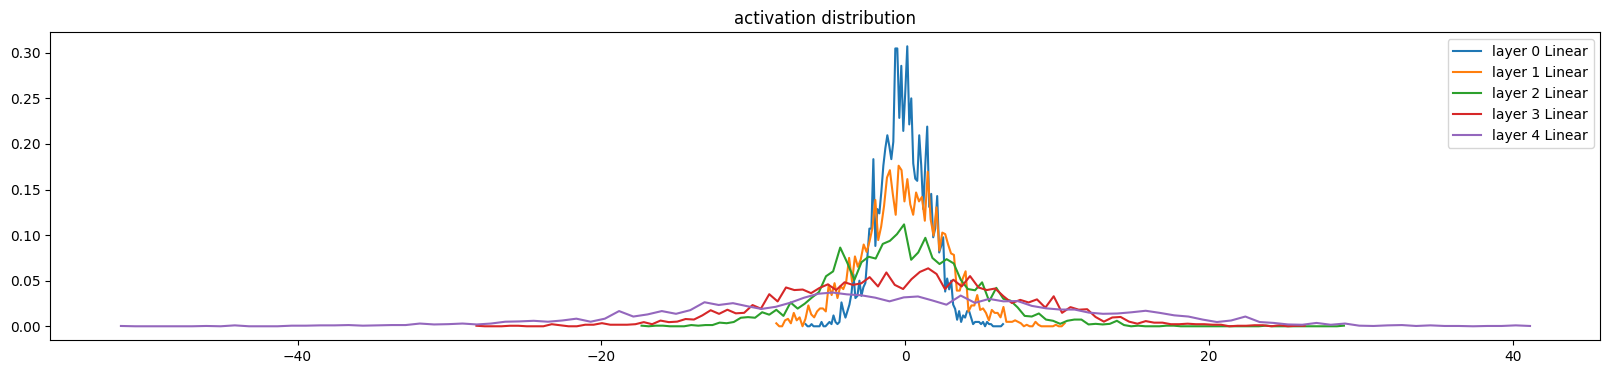

In [ ]:
# we're back to the extreme gradients
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Linear):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%') # recall, saturation is the percentage of white grids
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('activation distribution')

Metric to care about above is the increasing standard deviation.

The increasing saturation doesn't mean much given that there is no tanh, so effect of saturation causing dead neurons doesn't need to be accounted for.

layer 0 (Linear): mean +0.000053, std 2.619185e-03
layer 1 (Linear): mean -0.000006, std 1.583188e-03
layer 2 (Linear): mean +0.000043, std 9.519162e-04
layer 3 (Linear): mean +0.000019, std 5.457934e-04
layer 4 (Linear): mean -0.000013, std 3.161244e-04


Text(0.5, 1.0, 'gradient distribution')

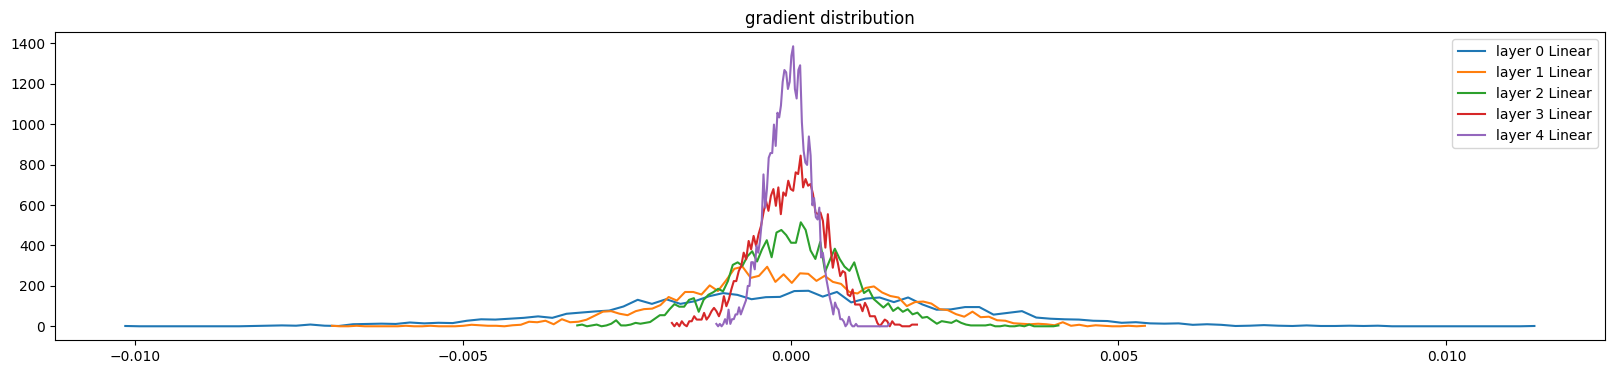

In [ ]:
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Linear):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('gradient distribution')


ideal value of gain without tanh would've been 1

### Visualize Parameter Gradient Histograms

**how does this help:** [grad:data] ratio indicates the proportion by which the gradient will affect the data. Ideally should only gently nudge the weights, not drastically transmogrify!

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_grad

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  break

      0/ 200000:3.2962


weight   (27, 10) | mean -0.000031 | std 1.365078e-03 | grad:data ratio 1.364090e-03
weight  (30, 100) | mean -0.000049 | std 1.207430e-03 | grad:data ratio 3.871660e-03
weight (100, 100) | mean +0.000016 | std 1.096730e-03 | grad:data ratio 6.601988e-03
weight (100, 100) | mean -0.000010 | std 9.893572e-04 | grad:data ratio 5.893091e-03
weight (100, 100) | mean -0.000011 | std 8.623432e-04 | grad:data ratio 5.158124e-03
weight (100, 100) | mean -0.000004 | std 7.388576e-04 | grad:data ratio 4.415211e-03
weight  (100, 27) | mean -0.000000 | std 2.364824e-02 | grad:data ratio 2.328203e+00


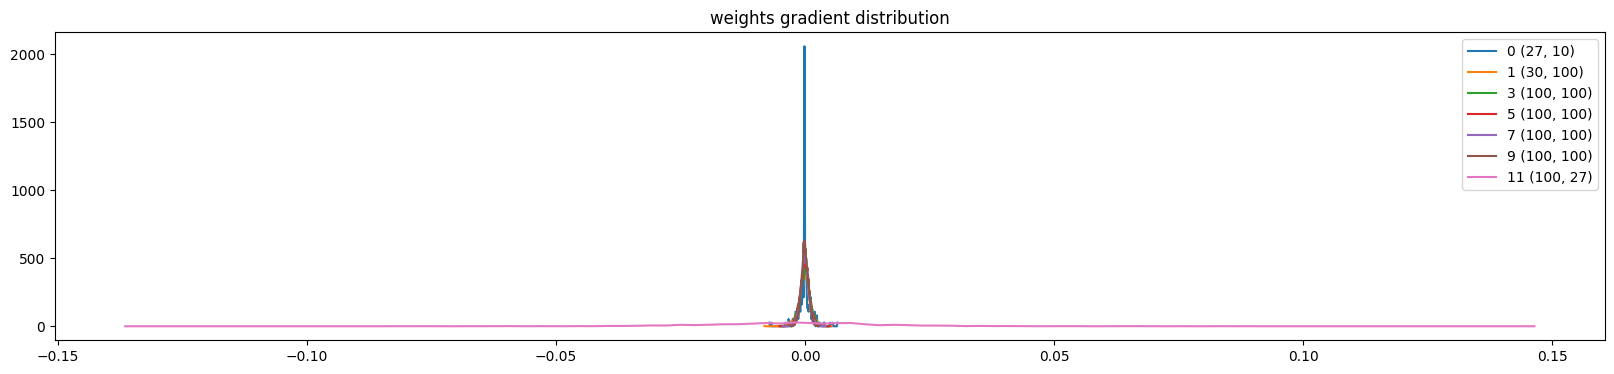

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

Observations:

1.   Gradient ratios at the last linear layer are really high
2.   the std of the last layer gradients is 10x higher than the max across other layers (also indicated by the long tails of the last layer gradients)--> this means gradient descent along these weights would be much faster compared to other weights --> fixes itself over time but still problematic



In [ ]:
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  if i>1000:
    break

      0/ 200000:3.2962


weight   (27, 10) | mean +0.000772 | std 9.714620e-03 | grad:data ratio 9.714506e-03
weight  (30, 100) | mean -0.000036 | std 8.734044e-03 | grad:data ratio 2.792835e-02
weight (100, 100) | mean +0.000085 | std 7.424625e-03 | grad:data ratio 4.417370e-02
weight (100, 100) | mean +0.000055 | std 6.242009e-03 | grad:data ratio 3.681915e-02
weight (100, 100) | mean +0.000007 | std 6.161662e-03 | grad:data ratio 3.650614e-02
weight (100, 100) | mean +0.000069 | std 5.221999e-03 | grad:data ratio 3.102274e-02
weight  (100, 27) | mean +0.000000 | std 2.281147e-02 | grad:data ratio 3.229574e-01


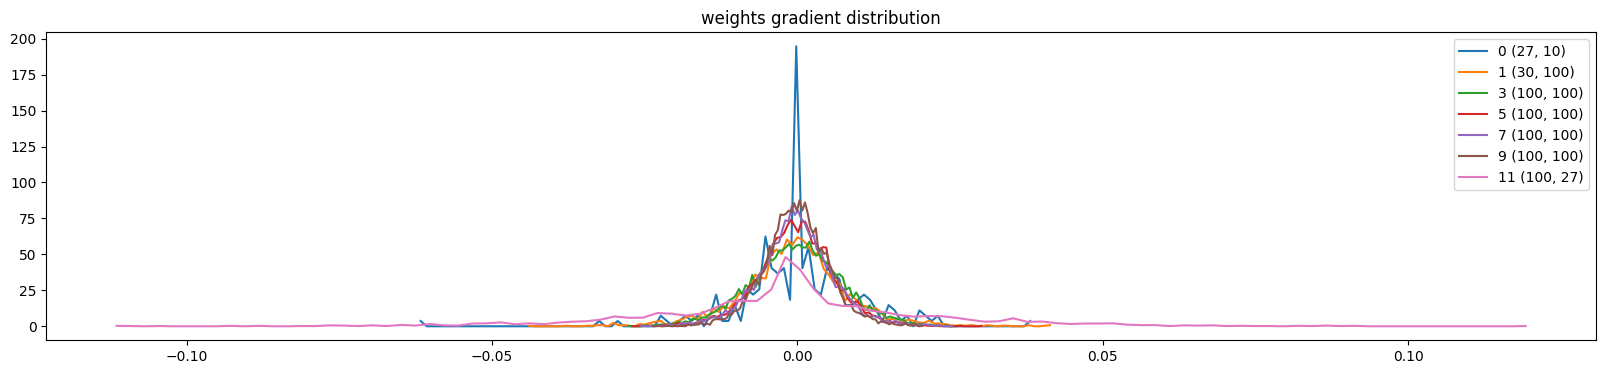

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

Notice how the tails curled inwards towards the center more now.

## Visualizing the update:data ratio instead of grad:data ratio

while grad:data ratio does give us some indication of the update discrepancies,
it would be even better if we could track the exact update(lr*grad):data ratios

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


46497


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

ud = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  with torch.no_grad():
    ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])

  if i>1000:
    break

      0/ 200000:3.2962


In [ ]:
for i, p in enumerate(parameters):
  if p.ndim == 2:
    print(len(ud))

1002
1002
1002
1002
1002
1002
1002


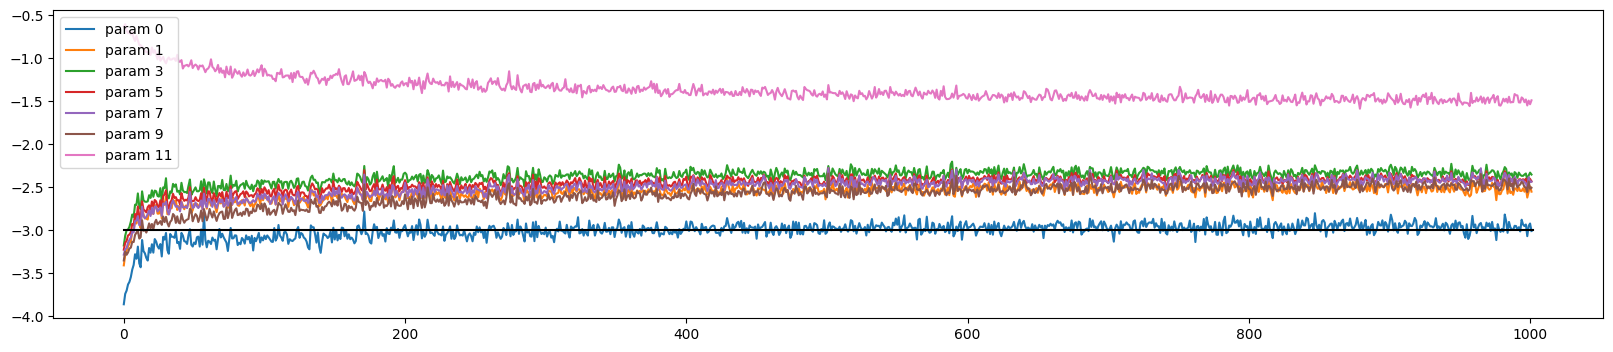

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    plt.plot([ud[j][i] for j in range(len(ud))]) # j indexes the epoch/step, i indexes the specific parameter appended to ud list
    legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

Since this is a log plot, and we want the updates to be ~1e-3, we want the log updates to be in range ~(-3).

Most layers do have updates close to the black -3 line.

Except for the last linear layer, but that is because it was artificially scaled down (the multiplication by 0.1). So it consistently, gets larger updates from the loss but the data always remains shrinked by the scaling down.
So naturally, the ratio of update:data is consistently high in the last layer.


#### How do parameter updates look when model trained with a very low learning rate?

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), Tanh(),
    Linear(hidden_size, vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  layers[-1].weight *= 0.1

  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

ud = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.001 #0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  with torch.no_grad():
    ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])

  if i>1000:
    break

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    plt.plot([ud[j][i] for j in range(len(ud))]) # j indexes the epoch/step, i indexes the specific parameter appended to ud list
    legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

## Parameter updates with Batch Norm

In [ ]:
# Squashing W1 and B1 and retraining for 1 step
vocab_size = 27
embed_size = 10
hidden_size = 100

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, embed_size),                generator=g)

# layers = [
#     Linear(block_size * embed_size, hidden_size),
#     BatchNorm1d(hidden_size),
#     Tanh(),
#     Linear(hidden_size, vocab_size)
# ]

layers = [
    Linear(block_size * embed_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, hidden_size), BatchNorm1d(hidden_size), Tanh(),
    Linear(hidden_size, vocab_size), BatchNorm1d(vocab_size)
]

with torch.no_grad():
  # last layer: make less confident
  # layers[-1].weight *= 0.1
  layers[-1].gamma *= 0.1 # last layer is now batchnorm which doesn't have weight
  # all other layers: apply gain
  for layer in layers[:-1]:
    if isinstance(layer, Linear):
      layer.weight *= (5/3)

# gather parameters

parameters = [C] + [p for layer in layers for p in layer.parameters()]

print(sum(p.nelement() for p in parameters))

for p in parameters:
  p.requires_grad = True


47551


In [ ]:
num_epochs = 200000
batch_size = 32
log_loss = []

ud = []

for i in range(num_epochs):
  # mini-batch
  ind = torch.randint(0, xTr.shape[0], (batch_size, ), generator=g)

  # forward-pass
  embed = C[xTr[ind]]

  x = embed.view(xTr[ind].shape[0], -1)

  # linear layer
  for layer in layers:
    x = layer(x)

  loss = F.cross_entropy(x, yTr[ind])

  for layer in layers:
    layer.out.retain_grad() # AFTER_DEBUG: would take out retain_graph

  for p in parameters:
    p.grad = None
  loss.backward()

  # lr decay
  lr = 0.1 if i < 100000 else 0.01
  # update-weights
  for p in parameters:
    p.data += -lr*p.grad

  # track stats
  if i%10000 ==0:
    print(f'{i:7d}/{num_epochs:7d}:{loss.item():.4f}')
  log_loss.append(loss.log10().item())

  with torch.no_grad():
    ud.append([((lr*p.grad).std()/p.data.std()).log10().item() for p in parameters])

  # if i>1000:
  #   break

      0/ 200000:2.2269
  10000/ 200000:1.8825
  20000/ 200000:2.2567
  30000/ 200000:2.0585
  40000/ 200000:2.1649
  50000/ 200000:2.0636
  60000/ 200000:2.0195
  70000/ 200000:1.9350
  80000/ 200000:2.2171
  90000/ 200000:2.2603
 100000/ 200000:2.2753
 110000/ 200000:1.9971
 120000/ 200000:2.1553
 130000/ 200000:2.1450
 140000/ 200000:2.1352
 150000/ 200000:2.0743
 160000/ 200000:2.3460
 170000/ 200000:1.9438
 180000/ 200000:2.2136
 190000/ 200000:2.1025


layer 2 (Tanh): mean -0.00, std 0.63, saturation 2.97%
layer 5 (Tanh): mean 0.01, std 0.64, saturation 2.41%
layer 8 (Tanh): mean -0.00, std 0.64, saturation 2.44%
layer 11 (Tanh): mean 0.00, std 0.64, saturation 2.22%
layer 14 (Tanh): mean -0.00, std 0.64, saturation 2.25%


Text(0.5, 1.0, 'activation distribution')

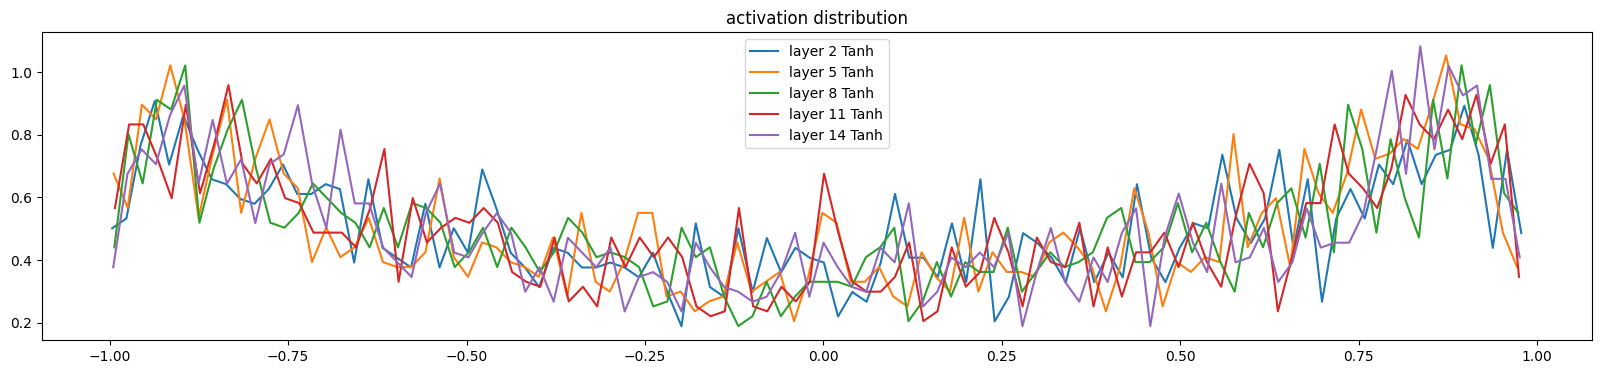

In [ ]:
# we're back to the extreme gradients
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out
    print(f'layer {i} ({layer.__class__.__name__}): mean {t.mean():.2f}, std {t.std():.2f}, saturation {(t.abs()>0.97).float().mean()*100:.2f}%') # recall, saturation is the percentage of white grids
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('activation distribution')

layer 2 (Tanh): mean +0.000000, std 3.561990e-03
layer 5 (Tanh): mean -0.000000, std 3.119532e-03
layer 8 (Tanh): mean +0.000000, std 2.904410e-03
layer 11 (Tanh): mean +0.000000, std 2.580227e-03
layer 14 (Tanh): mean -0.000000, std 2.440871e-03


Text(0.5, 1.0, 'gradient distribution')

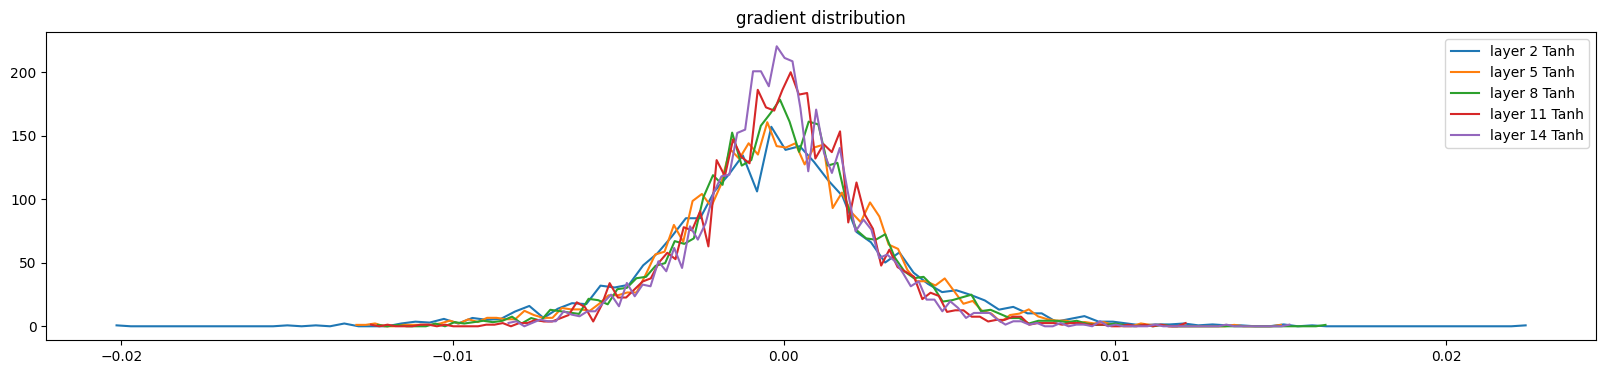

In [ ]:
# we're back to the extreme gradients
plt.figure(figsize=(20, 4))

legends = []

for i, layer in enumerate(layers[:-1]):
  if isinstance(layer, Tanh):
    t = layer.out.grad
    print('layer %d (%s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean(), t.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'layer {i} {layer.__class__.__name__}')

plt.legend(legends)
plt.title('gradient distribution')

weight   (27, 10) | mean -0.000000 | std 8.198672e-03 | grad:data ratio 8.190313e-03
weight  (30, 100) | mean -0.000195 | std 7.650407e-03 | grad:data ratio 2.447701e-02
weight (100, 100) | mean -0.000097 | std 6.207583e-03 | grad:data ratio 3.712882e-02
weight (100, 100) | mean +0.000015 | std 5.561924e-03 | grad:data ratio 3.297631e-02
weight (100, 100) | mean +0.000008 | std 5.220607e-03 | grad:data ratio 3.110155e-02
weight (100, 100) | mean +0.000029 | std 4.829167e-03 | grad:data ratio 2.876372e-02
weight  (100, 27) | mean -0.000014 | std 9.281224e-03 | grad:data ratio 5.568822e-02


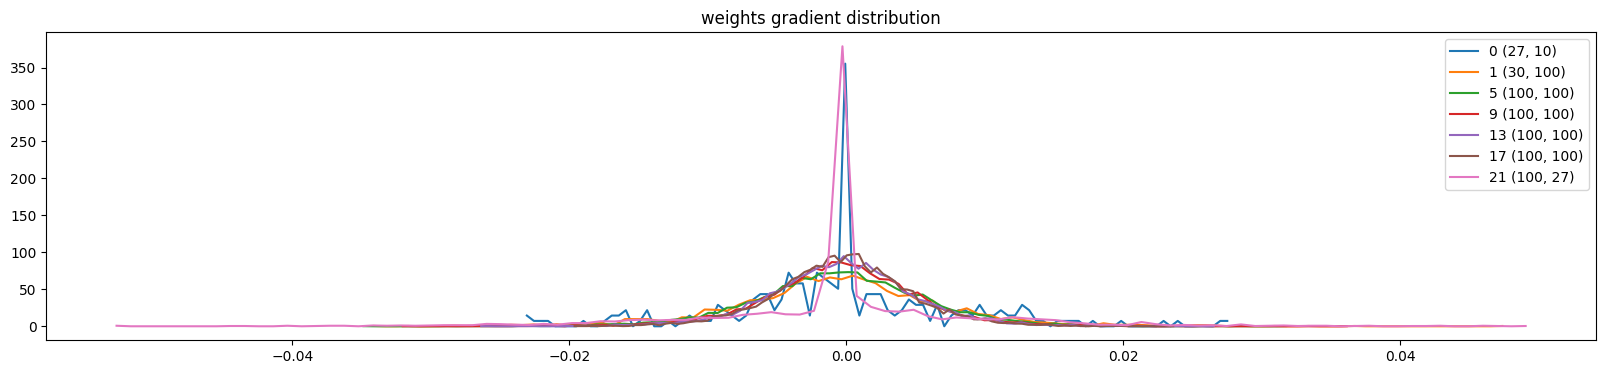

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  t = p.grad
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    print('weight %10s | mean %+f | std %e | grad:data ratio %e' % (tuple(p.shape), t.mean(), t.std(), t.std() / p.std()))
    hy, hx = torch.histogram(t, density=True)
    plt.plot(hx[:-1].detach(), hy.detach())
    legends.append(f'{i} {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution');

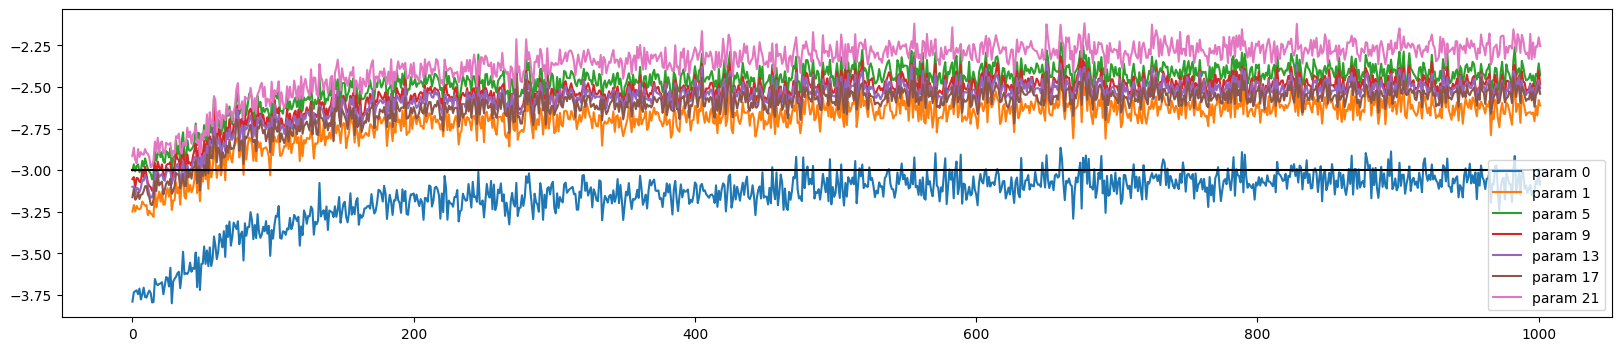

In [ ]:
# visualize histograms
plt.figure(figsize=(20, 4)) # width and height of the plot
legends = []
for i,p in enumerate(parameters):
  if p.ndim == 2: # plotting only the parameters that are 2 dimensional matrices, i.e weight parameters
    plt.plot([ud[j][i] for j in range(len(ud))]) # j indexes the epoch/step, i indexes the specific parameter appended to ud list
    legends.append(f'param {i}')
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);

In [ ]:
# decorator that disables gradient tracking
@torch.no_grad() # indicates to torch that I won't be calling backward on any of the computation within this function
def split_loss(split):
  datasets = {'train': (xTr, yTr),
              'val': (xVal, yVal),
              'test': (xTe, yTe)}
  x, y = datasets[split]

  # inference-pass
  embed = C[x] # shape (N, block_size, embed_size)
  # (N, block_size*embed_size)
  hpreact = embed.view(x.shape[0], -1)@ W1 + B1

  ##########  NEW  ##########
  hpreact = (bnscale*(hpreact - bnmean_running) / bnstd_running) + bnshift  # so even at validation and test time, train batch stats used to normalize
  ##########  NEW  ##########

  hidden = torch.tanh(hpreact) # (N, hidden_size)

  logits = hidden @ W2 + B2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)

  print(split, loss.item())

split_loss('train')
split_loss('val')

# TRANSCRIPT SUMMARY

Abstract Building makemore Part 3

This lecture highlights the importance of understanding activation and
gradient statistics for successful deep learning. While techniques
like batch normalization provide significant stability, understanding
these concepts remains crucial for building and analyzing deep neural
networks. Modern innovations like batch normalization and advanced
optimizers make training deep networks more manageable, but proper
initialization and diagnostic tools are still essential for achieving
optimal performance.

Summary

Initialization and Activations:
  -   Initial loss (4:25): High initial loss (e.g., 27) indicates improper network initialization.
        - Softmax logits should be close to zero at initialization to produce a uniform probability distribution and expected loss.
        - This avoids confident mispredictions and the "hockey stick" loss curve.
        - Scaling down weights of the output layer can achieve this (9:28).
  -   Saturated activations (13:09): Tanh activations clustered around -1 and 1 indicate saturation, hindering gradient flow.
        - Saturated neurons update less frequently and impede training.
        - This can lead to dead neurons, which never activate and don't learn (19:19).
        - Scaling down weights of the hidden layer can help prevent saturation (24:59).
  -   Kaiming initialization (27:58): A principled approach to weight scaling, aiming for unit gaussian activations throughout the network.
        - Calculates standard deviation based on fan-in and gain factor specific to the non-linearity used (31:46).
        - PyTorch offers torch.nn.init.kaiming_normal_ for this (33:56).

Batch Normalization (40:49):
  -   Concept: Normalizes activations within each batch to be roughly unit gaussian.
        - Controls activation scale, stabilizing training and mitigating the need for precise weight initialization.
        - Offers a regularization effect due to coupling examples within a batch (51:55).
  -   Implementation (42:17):
        - Normalizes activations by subtracting batch mean and dividing by batch standard deviation (42:41).
        - Learnable gain and bias parameters allow the network to adjust the normalized distribution (45:54).
        - Running mean and variance are tracked during training and used for inference (54:38).
  -   Caveats:
        - Couples examples within a batch, leading to potential bugs and inconsistencies (50:20).
        - Requires careful handling at inference time due to batch dependency (54:03).
        - Makes bias terms in preceding layers redundant (1:01:37).

PyTorch-ifying the code (1:18:40):
  -   Code is restructured using torch.nn.Module subclasses for linear, batch normalization, and tanh layers (1:19:26).
  -   This modular approach aligns with PyTorch's structure and allows easy stacking of layers.
  -   Default PyTorch initialization schemes and parameters are discussed (1:08:52).

Diagnostic Tools (1:19:13):
  -   Visualization of statistics: Histograms of activations, gradients, weights, and update:data ratios reveal potential issues during training (1:26:53).
  -   Forward pass activations: Should exhibit a stable distribution across layers, indicating proper scaling (1:26:53).
  -   Backward pass gradients: Should be similar across layers, signifying balanced gradient flow (1:30:57).
  -   Parameter weights: Distribution and scale should be monitored for anomalies and asymmetries (1:36:20).
  -   Update:data ratio: Should be around -3 on a log scale, indicating a good learning rate and balanced parameter updates (1:39:56).